# Práctica módulo Bases de Datos Vectoriales

In [219]:
%load_ext autoreload
%autoreload 2
from utils import (load_data, project_root,
                    recall_at_k, nDCG_at_k, MRR_at_k, result_analysis, 
                    text_parser, parse_corpus, embed_documents_ge1, embed_documents_ge2, run_query_dense, run_query_sparse, evaluate_compare_queries,
                    db_ingestion, db_query, db_modify
)

import numpy as np
import pandas as pd
import os
import time

from bm25_vectorizer import BM25Vectorizer

import chromadb

import json

from tabulate import tabulate
from IPython.display import display, HTML

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


#### En lo que sigue se describe el ejercicio. Ver apartados de la izquierda. En el apartado `DOCSTRINGS` se puede encontrar la descripción de las funciones creadas para la práctica, contenidas en `utils.py`. En los aparatados se da una descripción a alto nivel, para el detalle mejor ir a `DOCSTRINGS`

## 1. Carga y análisis de datos
Se cargan a pandas DataFrames los datos para desarrollo y evaluación. Se usa la función **`load_data(file: str, key: set) -> pd.DataFrame`** para ello. 
Previamente se han inspeccionado en Excel. Para cada tabla se selecciona una de las columnas como índice.

### 1.1 Datos para desarrollo

In [2]:
# para catalogo muestra se selecciona product_id como índice en tanto que se ha comprobado que es único y que es el campo relevante para la identificación del registro a nivel de análisis de los datos
catalogo_muestra = load_data('catalogo_muestra.csv', 'product_id')

consultas_desarrollo = load_data('consultas_desarrollo.csv', 'query_id')

# no tiene clave única; de hecho la clave única sería con un multi-índice de query_id + prodcut_id
relevancias_desarrollo = load_data('relevancias_desarrollo.csv', 'product_id')

eventos_catalogo = load_data('eventos_catalogo.csv', 'event_id')

altas_desarrollo = load_data('altas_desarrollo.csv', 'incoming_id')

- `product_id` es la clave de samp (catalogo_muestra), dado que no tiene duplicados
- el campo `color` vacío en un 36% de los registros. Ademñas se ha visto que hay textos que no se corresponden a color. Se considera que el campo no es útil y se evitará.
- el campo `brand`vacío en un 3% de los registros. Aun así se considera útil
- no hay ningún registro en la muestra sin palabras en `title`y `text`. En un procesado del completo esto se deberá tener en cuenta
- la longitud de los campos `title`y `text` son razonables y con una distribución aproximadamente uniforme. Hay casi 50 registros de los 1500 con sin palabras en `text`, pero ninguno sin palabras el `title`, por lo que todos contienen algún tipo de información; se toma la decisió de no filtrar ninguno fuera
- en la mustra todos los registros estan 'activos' (productos realmente disponibles, se entiende; este campo podría servir para gestiionar un índice HNSW sin tener que actulizarlo con las variaciones en el catálogo; modificarlo lleva tiempo dado que el cálculo del grafo es complejo -, filtrando por 'active' antes de devolver los resultados)


In [4]:
catalogo_muestra.isna().sum()/len(catalogo_muestra)

record_id          0.000000
title              0.000000
brand              0.029333
color              0.366000
locale             0.000000
text               0.000000
catalog_version    0.000000
active             0.000000
dtype: float64

<Axes: title={'center': 'distribución num palabras en "title"'}, xlabel='Número de palabras', ylabel='Frecuencia'>

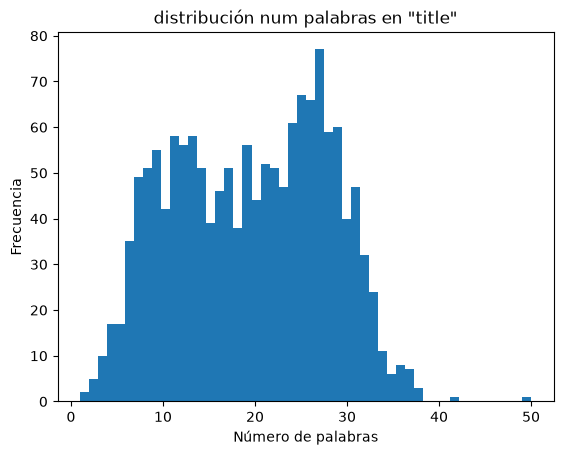

In [5]:
catalogo_muestra['title'].apply(lambda x: len(x.split(' '))).plot(kind='hist', bins=50, title='distribución num palabras en "title"', xlabel='Número de palabras', ylabel='Frecuencia')

<Axes: title={'center': 'distribución num palabras en "text"'}, xlabel='Número de palabras', ylabel='Frecuencia'>

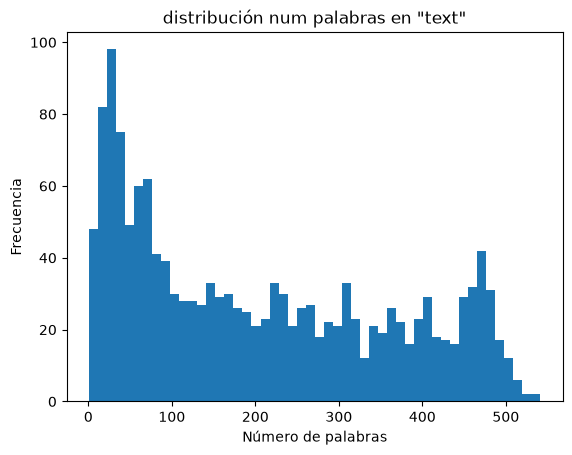

In [6]:
# hay bastantes textos largos, pudiendo llegar a 3000 c
catalogo_muestra['text'].apply(lambda x: len(x.split(' '))).plot(kind='hist', bins=50, title='distribución num palabras en "text"', xlabel='Número de palabras', ylabel='Frecuencia')

### 1.2 Datos para evaluación

In [67]:
consultas_evaluacion = load_data('consultas_evaluacion.csv', 'evaluation_id')

In [187]:
altas_evaluacion = load_data('altas_evaluacion.csv', 'incoming_id')

In [68]:
consultas_filtradas = load_data('consultas_filtradas.csv', 'workload_id')

In [69]:
eventos_catalogo = load_data('eventos_catalogo.csv', 'event_id')

## 2 Construcción del sistema

## 2.1 Representación y baseline

Se van a comparar dos representaciones dense y una sparse. 

Los campos que se consideran informativos del producto son `title`, `text` y `brand`. 
El campo `color`, tiene un 36% de valores ausentes y puede contener valores que no se corresponden a lo que es un color. No se considera un campo útil.

`brand` tiene un 3% de registros con información ausente. 
- Se observa que la marca puede aparecer en `title`o en `text`. Primero se observa que en `text`a menudo aparece la cadena definida por el regex r'(Marca :+?\.), es decir, la cadena 'Marca: ' seguida de un nombre de marca seguida de un punto. Se prueba y no da resultado, se termina conexactamente el mismo númeoro de na's
- Se intenta a sanar `brand` buscando en `text` o `title` de los registros que lo tienen vacío una marca ya presente en `brand`. Con ello se baja el porcentaje de registros con `brand`vacío al 1.73%. Donde no hay merca se va a asignar el valor *unknown*.

Por lo que es el texto a codificar, ya sea representación sparse o densa, se decide incluir `text`, `title` y `brand`, previamente habiendo cambiado *unknown* a *texto vacío* en `brand` y llevando a cabo un tratamiento para facilitar la tarea de representación, que está ecapsulado en la función **`text_parser(text)`**:

    - .astype(str) # se asegura que todos los campos sean de tipo string
    - .fillna('') # se rellenan los campos sin información con cadena vacía
    - .str.lower() # se pasa todo a minúscula
    - .str.replace(r'[^a-z0-9À-ÿ\s]', ' ', regex=True) # se sustituye cualquier caracter que no sea alfanumérico por un espacio
    - .str.split() # separa en palabras (el separador es el espacio blanco)
    - .str.join(' ') # junta de nuevo con un espacio entre palabaras


Codificar los tres ayuda a dar mayor peso a las palabras que más información aportan: la marca, que a menudo se va a repetir tres veces, y otras palabras clave que aparecerán en el título además de en el texto, dado que el título, al ser un resúmen del texto, va a tender a contenerlas

Una mejora podría ser estandarizar en el texto y en el título como se hace referencia a las medidas (por ejemplo convertir r'(\d+x\d+)' a r'(\d+ x \d+)', dado que soun un dato determinante por sí solo, como la marca

Se adapta la codificación de los documentos para ambos modelos al esquema `title: {title} | text: {content} | marca: {brand}`, que así se adapta al esperado por `gemini-embedding-2` y también es válido para`gemini-embedding-001`

El procesado de `catalogo_muestra` para obtener el listado de textos a codificar se lleva a cabo con la función **`parse_corpus(corpus) -> pd.DataFrame`**

Para la generación de mebeddings se usan las funciones `embed_documents_ge1`y `embed_documents_ge2`, para modelos `gemini-embedding-001`y `gemini-embedding-2`respectivamente. Más abajo se detalla el interfaz. Los vectores devueltos son normalizados.

Para la generación de las queries en dense matrix, se usa la función **`run_query_dense(name, corpus_embeddings, query_embeddings, corpus_index, query_inde, k=10): -> pd.DataFrame`** . Dado que los embeddings son normalizados, se usa el producto escalar para calcuar la distacia coseno, dado que el producto escalar es una operación simple y que al ser los vectores unitarios su producto es igual al coseno del ángulo que forman. El coseno crece de 0 a 1 cuando de varía el angulo de 0º  a 90º, por lo que la relevancia viene dada por el óden de más a menos de los scores.

Para la generación de las queries en sparse matrix, se usa la función **`run_query_sparse(name:, vectorizer: BM25Vectorizer, queries, corpus_index, k= 10) -> pd.DataFrame`**. `vectorizer` es un objeto del package `BM25Vectorizer` que contiene una matriz sparse codificada con IDF e implementa un buscador con ranking BM25 según los parámetros k1 y b pasados en el constructor (permite varias variantes, se ha usado la 'básica'; ver más abajo). Las queries a `vectorizer`se pasan como texto, no es necesario codificarlas primero, lo hace internamente (las codifica, realiza los productos vectoriales y aplica ponderación - ranking - por bm25)

Ambas funciones deveulven un dataframe con una columna por query, identificada por `query_id` conteniendo el ranking ordenado por relevancia de los primeros `k` (parámetro función) `product_id`'s. Los índices para mapear columnas a `query_id`'s y fila de la matriz de embeddings de documentos a `product_id` se pasan como parámetro y usan la propiedad de que se respeta el orden de los documentos y queries en las matrices de codificación.

Para comparar el resultado de un mismo conjunto de queries contra matrices de distintas codificaciones, se usa la función **`evaluate_compare_queries(metric, rank_df_list, labeled_query_results, valid_esci_labels) -> pd.DataFrame`**, en la que comom parámetros se pasan una lista de métricas a calcular (peuden ser `recall_at_k`, `nDCG_at_k` o `MRR_at_k`) para un listado de resultados de un mismo grupo de queries aplicadas a distintas codificaciones y usando las relevancias de los posibles resultados de esas queries filtrado por las etiquetas de interés. Devuelve un dataframe que resume toda la información

In [10]:
marca_extracted = catalogo_muestra['text'].str.extract(r'(Marca: .+?\.)', expand=False).str[7:]
marca_extracted.isna().sum()/len(marca_extracted)

np.float64(0.088)

In [11]:
brand = catalogo_muestra['brand']
brand.loc[brand.isna()] = marca_extracted[brand.isna()]
brand.isna().sum()/len(brand)

np.float64(0.029333333333333333)

In [12]:
brand = catalogo_muestra['brand']
brands = brand.value_counts().index
def fill_brand(row):
        return next((brand for brand in brands if brand in row['title'] or brand in row['text']), 'unknown')
brand.loc[brand.isna()] = catalogo_muestra[brand.isna()].apply(lambda x: fill_brand(x), axis=1)
brand.apply(lambda x: x=='unknown').sum()/len(brand)

np.float64(0.017333333333333333)

### 2.1.1 Representación densa de los documentos con `gemini-embedding-001` (https://ai.google.dev/gemini-api/docs/embeddings)

- En este modelo el 'pefijo', esto es, el tipo de embedding a crear se indica con el parámetro `task_type`: 'RETRIEVAL_DOCUMENT' para generar la matriz de documentos y 'RETRIEVAL_QUERY' para las queries a lanzar sobre la matriz. 
- `gemini-embedding-001` usa una representación tipo MRL (Matryoshka Representation Learning). Se recomienda no usar una dimensionalidad inferior a `768`. Dado que `docs` es un corpus pequeño, se usa la inferior, en tanto que optimiza recursos y evita el reducir distancias por concentración en una fracción de dimensiones si el rango del espacio vectorial subyacente es muy inferior al número de dimensiones. La matriz resultante se normaliza para poder usar similitud coseno (al tomar solamente una parte de las componentes la normalización, referida al vector completo, se pierde)
- para evitar superar límite de concurrencia de la api el procesado se hace en batches de 100
- se está lejos del máximo número de tokens por request (8192, los documentos deben estar por debajo de las 600 palabras, unos 750 tokens)

Se define la función **`embed_documents_ge1(documents: pd.Series, task_type: Literal['RETRIEVAL_DOCUMENT', 'RETRIEVAL_QUERY'], output_dimensionality: Literal[768, 1536, 3072], batch_size: int = 100) -> np.ndarray`** que encapsula la generación de los embeddings, normalizados
La matriz densa generada se guarda en la variable `doc_embeddings_ge1`

Se intentó con un modelo en local (`e5-multilingula-small`) pero pc no soportaba la carga.

In [3]:
# SE PARSEA EL CORPUS
corpus = parse_corpus(catalogo_muestra)
corpus.head(3).T

product_id,B0818K237B,B086YX9RK5,B07FRXCFJ1
record_id,000bd6e8-a995-56d0-ba03-559885ccef39,0037a9df-8492-508f-8167-c09624801216,003a8544-5ab1-5c8e-8fa5-612989e4a7a8
title,Kanlin1986 Vestido Largo De Navidad para Mujer...,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g,ELINKUME Lámpara de pie regulable LED Lámpara ...
brand,KanLin1986-Ropa,IQOS,ELINKUME
color,Negro,NaN,Lámparas de Pie-espiral Estilo-regulable Led
locale,es,es,es
text,Kanlin1986 Vestido Largo De Navidad para Mujer...,IQOS Kit Iqos 3 Duo Blue Opk 1 200 g. Marca: I...,ELINKUME Lámpara de pie regulable LED Lámpara ...
catalog_version,1,1,1
active,True,True,True
string2embed,title: kanlin1986 vestido largo de navidad par...,title: iqos kit iqos 3 duo blue opk 1 200 g | ...,title: elinkume lámpara de pie regulable led l...


In [4]:
# SE PARSEAN LAS QUERIES
parsed_queries = text_parser(consultas_desarrollo['query_text'])
parsed_queries.head(3)

query_id
13357        base tapizada 160x200 sin patas
18868     botines marrones mujer tacon medio
28703    convertibles 2 en 1 portátil tactil
Name: query_text, dtype: object

Con un batch de 100 hoy se está disparando el siguiente error: *ClientError: 429 RESOURCE_EXHAUSTED. {'error': {'code': 429, 'message': 'Quota exceeded for aiplatform.googleapis.com/global_embed_content_requests_per_minute_per_base_model with base model: gemini-embedding. Please submit a quota increase request. https://cloud.google.com/vertex-ai/docs/generative-ai/quotas-genai.', 'status': 'RESOURCE_EXHAUSTED'}}*. Es un error que depende de la carga de la infraestructura de genai. Con un plan 'Provisioned Throughput' no de daría. Esto desvirtúa cualquier medida que se quiera hacer de thrpughput con el plan actual. Lo que sí que se ha observado es que con output_dimensionality=1536 ha tardado mucho más

Pricing: *https://aistudio.google.com/docs/pricing?_gl=1*hxel7j*_up*MQ..&gclid=Cj0KCQjw79nUBhCgARIsADSHka1KXTKIzTwhGglPiH2cZizwqhzg_MrYSzSL8bfipGjN0nYVayrEQkEaAiFHEALw_wcB&gbraid=0AAAAACn9t66cniy5TAevQp86WIp92T9mE*

Se ha implmentado un sistema de backoff mediante el decorador @retry(wait=wait_random_exponential(multiplier=1, max=60))

In [6]:
# SE REPRESENTAN LOS DOCUMENTOS EN gemini-embedding-001 con 768 dimensiones
corpus_dense_matrix_ge1 = embed_documents_ge1(corpus['string2embed'], 'RETRIEVAL_DOCUMENT', batch_size=100, output_dimensionality=768)
corpus_dense_matrix_ge1.shape

(1500, 768)

In [7]:
# SE REPRESENTAN LAS QUERIES EN gemini-embedding-001 con 768 dimensiones
query_dense_ge1 = embed_documents_ge1(parsed_queries, 'RETRIEVAL_QUERY', batch_size=100, output_dimensionality=768)
query_dense_ge1.shape

(8, 768)

In [8]:
# EJECUCIÓN QUERIES EN EN gemini-embedding-001 con 768 dimensiones
rank_ge1 = run_query_dense ('rank_ge1', corpus_dense_matrix_ge1, query_dense_ge1, corpus.index, parsed_queries.index, k=10)
rank_ge1

,13357,18868,28703,31224,33633,38249,43240,61533
0,B01MV80F5C,B06X9WSSLL,B08GYFBKD4,B006Q8VAL8,B07NY97H69,B09BHVMCC3,B08MJBJWLP,B01I5JVBZK
1,B015FMZ4MQ,B07H97VGBP,B083BM815K,B07HP6XKC6,B07XD9D2HB,B087Q5SLQT,B08MQ42Z6P,B01M31TMH8
2,B09BW133YW,B0714N7942,B08RZ19NDS,B01MU31H1P,B07HHX8TNL,B08CDNV942,B08KTS1FZT,B085WY78SG
3,B091BWS8VF,B07G1DXKV2,B07XT5ZSJD,B01B98IYPY,B00NKZ0C96,B08BWTFMV4,B08KPYKNWZ,B0837V9T36
4,B07DBQNP1X,B08T9X4XT6,B08HZ3YBPH,B01NADH8A4,B0161N7XAO,B08HQJQRHT,B08LVQPZQD,B00WGOY7O8
5,B091BB18QV,B07GJNCV8R,B08PFJVLGD,B019GL1854,B07TFKMTJ8,B08Y8G4F6K,B08ZS57R32,B07QB8484Y
6,B096W9CNHN,B071RN7FHT,B08MCDPVCJ,B01C672VK6,B07S9W5P46,B08FMH2YHQ,B08FT5QDWJ,B079ZYKLFD
7,B0937C9GTY,B07GN7XRQ9,B08PFK1TTF,B00BIFWNV0,B07Z8N7Z3K,B094GS9X92,B08MSR1SJS,B07FNQ3DHK
8,B07BFFKCHC,B00475B94U,B08FC69VMH,B01LNNBP9W,B07WGHD2Z7,B082PR44HT,B08L1XPVFD,B07QB8484X
9,B096ZLG8GF,B07H2Y8R6Y,B08PFJXSW5,B07KQ1GFYD,B07XM84G9L,B00OXNEU5Q,B08N6MJYNM,B01MSTVEZN


In [9]:
# SE REPRESENTAN LOS DOCUMENTOS EN gemini-embedding-001 con 1536 dimensiones
corpus_dense_matrix_ge1_1536 = embed_documents_ge1(corpus['string2embed'], 'RETRIEVAL_DOCUMENT', batch_size=100, output_dimensionality=1536)
corpus_dense_matrix_ge1_1536.shape

(1500, 1536)

In [10]:
# SE REPRESENTAN LAS QUERIES EN gemini-embedding-001 con 768 dimensiones
query_dense_ge1_1536 = embed_documents_ge1(parsed_queries, 'RETRIEVAL_QUERY', batch_size=100, output_dimensionality=1536)
query_dense_ge1_1536.shape

(8, 1536)

In [11]:
# EJECUCIÓN QUERIES EN EN gemini-embedding-001 con 1536 dimensiones
rank_ge1_1536 = run_query_dense ('rank_ge1_1536', corpus_dense_matrix_ge1_1536, query_dense_ge1_1536, corpus.index, parsed_queries.index, k=10)
rank_ge1_1536

,13357,18868,28703,31224,33633,38249,43240,61533
0,B01MV80F5C,B07H97VGBP,B083BM815K,B006Q8VAL8,B07NY97H69,B09BHVMCC3,B08MJBJWLP,B01I5JVBZK
1,B015FMZ4MQ,B06X9WSSLL,B08GYFBKD4,B07HP6XKC6,B07XD9D2HB,B08BWTFMV4,B08KTS1FZT,B01M31TMH8
2,B091BWS8VF,B0714N7942,B07XT5ZSJD,B01MU31H1P,B07HHX8TNL,B08CDNV942,B08MSR1SJS,B079ZYKLFD
3,B09BW133YW,B07GJNCV8R,B08HZ3YBPH,B01B98IYPY,B07S9W5P46,B087Q5SLQT,B08MQ42Z6P,B07QB8484Y
4,B091BB18QV,B08T9X4XT6,B08RZ19NDS,B019GL1854,B0161N7XAO,B08HQJQRHT,B096ZQXB5P,B00WGOY7O8
5,B07DBQNP1X,B071RN7FHT,B08PFJVLGD,B01NADH8A4,B07Z8N7Z3K,B08FMH2YHQ,B08LVQPZQD,B07QB8484X
6,B0937C9GTY,B07G1DXKV2,B08MCDPVCJ,B000IHYS2Q,B07TFKMTJ8,B08Y8G4F6K,B08KPYKNWZ,B085WY78SG
7,B096W9CNHN,B07GN7XRQ9,B08PFJXSW5,B07KQ1GFYD,B00NKZ0C96,B082PR44HT,B08N6MJYNM,B0837V9T36
8,B08JM5M345,B07H2Y8R6Y,B08PFK1TTF,B012T29V06,B07WGHD2Z7,B094GS9X92,B08FT5QDWJ,B07FNQ3DHK
9,B07BFFKCHC,B00475B94U,B08FC69VMH,B01LNNBP9W,B07XM84G9L,B07WT1ZWG3,B08ZS57R32,B01MSTVEZN


#### 2.1.1.1 Comparativa dimensionalidad 768 vs 1536
Se aprecia que el resultado es prácticamente igual, con ambas dimensionalidades, concretamente la única diferencia es en el MRR de la query 18868 para el caso de solemente considerar como válidas las etiquetas 'E' para recall y MRR. **Se escoge `768` en adelante, dado que la diferencia en recursos no justifica la diferencia en resultado,**
Se ha hecho la comparativa teniendo solamente en cuenta la esci label 'E', la de mayor ponderación, dado que se considera que ampliarlo a otras puede 

Se observa que al al incluir la etiqueta 'S' además de 'E' el recall en general baja y el MRR mejora. El motivo es que en general aumenta más el denominador (resultados considerados válidos) que el numerador (resultados válidos entre los 10 primeros) en el primer caso y que es más probable encontrar entiquetas válidas en las primeras posiciones en el segundo

In [12]:
# COMPARATIVA rank_ge1 (gemini-embedding-001 con 768)  CON rank_ge1_1536 gemini-embedding-001 con 1536)
evaluate_compare_queries ( metrics=['recall', 'nDCG', 'MRR'], 
                           rank_df_list=[rank_ge1, rank_ge1_1536], 
                           labeled_query_results_sorted=relevancias_desarrollo, 
                           valid_esci_labels=['E'])

recall@10                 nDCG@10                 MRR@10              
       rank_ge1 rank_ge1_1536  rank_ge1 rank_ge1_1536 rank_ge1 rank_ge1_1536
13357  0.500000      0.500000  0.788930      0.780096      1.0           1.0
18868  0.857143      0.857143  0.830332      0.842324      0.5           1.0
28703  0.360000      0.360000  0.973867      0.973867      1.0           1.0
31224  0.800000      0.800000  0.839310      0.845955      0.5           0.5
33633  0.000000      0.000000  0.461517      0.460788      0.0           0.0
38249  0.233333      0.233333  0.915101      0.915720      1.0           1.0
43240  0.291667      0.291667  0.914042      0.895824      1.0           1.0
61533  0.400000      0.400000  1.000000      1.000000      1.0           1.0

In [65]:
consultas_desarrollo['query_text']

query_id
13357          base tapizada 160x200 sin patas
18868       botines marrones mujer tacon medio
28703      convertibles 2 en 1 portátil tactil
31224                   cámaras bridge baratas
33633    disfraz halloween talla grande hombre
38249          estantes sin taladro habitacion
43240                funda ipad air 4 sin tapa
61533                      lentejas sin gluten
Name: query_text, dtype: str

#### 2.1.1.2 Análisis más allá de la comparativa, búsqueda de razones, corrección de la tabla de relevancias
Se ve que hay algunos recall muy bajos, lo que es raro, dado que se recogen 10 resultados. En concreto para la consulta 33633 (recall 0 con si con solamente 'E'). Se analizan las consultas con `result_analysis` y se ve que el problema está en que las etiquetas de `consultas_desarrollo` están mal en algunos casos y en otro sel problema viene por motivos relacionados con como está formulada la pregunta o dificultades inherentes a la búsqueda semántica. Se hace un análisis rápido y se ve que:
- **13357**: El problema está en errores en devr (relevancias_desarrollo), que tiene marcados com 'E' dos productos que claramente no deberían; en todo caso podrian considerarse 'S'
- **28703**: 'táctil' está escrito sin acento. la cadena 'convertibles 2 en 1 portatil tactil' de por sí está mal expresada, algo como 'ordenador portátil con pantalla tácil' sería mejor. En el contexto de un RAG, Una forma de solventar este tipo de problemas podría ser generar frases (2 o 3) con el mismo sentido con un LLM y hacer la query con todas ellas seguida de un reranking
- **31224**: ni en el título ni en las descripciones viene el precio; si baratas son las que están por debajo de la mediana de precio, debería resultar en un 50%, aprox
- **31224**: se ha analizado devr y se ha visto que como en el caso de 13357 las etiquetas 'E' estan mal
- **38249**: habitación sin acento. en la descripción de las 'E' viene como 'estante flotante'; asociar eso a 'sin taladro' no es trivial
- **43240**: 'ipad air' al ser una marca se detectaría mejor con un buscador léxico. En bastantes descripciones no se hace referencia a si lleva tapa o no
- **61533**: las lentejas nunca llevan gluten; jamás en los embeddings de lentejas vendra 'codificado' 'sin gluten', por lo que 'sin gluten' en realidad está dapartando la query de lo que se pretende

In [20]:
# ANÁLISIS CONSULTA 33633
result_analysis (query_id=33633, valid_esci_labels=['E'], ranked_docs=rank_ge1, relevances=relevancias_desarrollo, docs=corpus['string2embed'], devq=consultas_desarrollo, chop=500)

product_id,string2embed
B07GSVQG2R,title: blusa mujer sexy bbestseller camiseta de otoño e invierno manga larga con estampado de fantasmas y estampado fantasma de halloween para mujer | text: blusa mujer sexy bbestseller camiseta de otoño e invierno manga larga con estampado de fantasmas y estampado fantasma de halloween para mujer marca bbestseller tops de mujer | marca: bbestseller tops de mujer


product_id,string2embed
B07NY97H69,title: larga capa de vampiro diablo de terciopelo con capucha para disfraz de fiesta halloween y carnaval talla unica para adulto mujeres hombres negra | text: larga capa de vampiro diablo de terciopelo con capucha para disfraz de fiesta halloween y carnaval talla unica para adulto mujeres hombres negra marca cotigo color negra características 1 incluye 1pcs capa con capucha 2 materiales hecho de alta calidad durable terciopelo telas elástico suave y cómodo 3 medidas 135cm desde el hombro talla
B07XD9D2HB,title: new largo capa con capucha terciopelo disfraz de halloween para mujeres hombres halloween fiesta disfraces | text: new largo capa con capucha terciopelo disfraz de halloween para mujeres hombres halloween fiesta disfraces marca mujer feliz color gris características mujer vestido corto elegante sexy cuello v raya talla grande top puro con manga dama de honor para boda noche fiesta y boda navidad s 19xl sudadera con capucha suéter hoodies pullover outwear encapuchado tops de manga larga pa
B07HHX8TNL,title: tianxinxishop disfraz de jon snow para hombre disfraz de rey knight medieval traje capa de guerrero conjunto completo l | text: tianxinxishop disfraz de jon snow para hombre disfraz de rey knight medieval traje capa de guerrero conjunto completo l marca tianxinxishop color version 2 características disfraz de jon snow para hombre disfraz de rey knight medieval traje capa de guerrero conjunto completo l incluyendo abrigo ropa interior capa guantes 2 ropa de la muneca 2 armadura babero cint
B00NKZ0C96,title: traje traje de star wars jedi de estilo bata bolsa de almacenamiento traje sobre 165cm unos 180 cm | text: traje traje de star wars jedi de estilo bata bolsa de almacenamiento traje sobre 165cm unos 180 cm marca yts características contenido de materia x1 bata bolsa de almacenamiento x1 tamano longitud cerca de 140 cm de altura estaendar aproximadamente 165cm 180cm alrededor color robe bolsa de almacenamiento negro o marroen amarillento cada color coedigo de la compania gs1 ha sido adquir
B0161N7XAO,title: guirca disfraz adulta súperstar talla 38 40 80841 0 | text: guirca disfraz adulta súperstar talla 38 40 80841 0 marca guirca color come da foto características incluye mono y antifaz perfecto para disfrazarse de super heroína talla 38 40 | marca: guirca
B07TFKMTJ8,title: mujer feliz disfraz costume niña princesa disfraz vestido niña traje adventure infantil para carnaval halloween cosplay s m l xl xxl xxxl | text: mujer feliz disfraz costume niña princesa disfraz vestido niña traje adventure infantil para carnaval halloween cosplay s m l xl xxl xxxl marca mujer feliz color negro características vestidos mujer casual verano vestido playa mujer vestido blanco mujer vestido largo negro vestido negro largo vestido largo negro vestido negro mujer vestido negro
B07S9W5P46,title: eraspooky mamá noel deluxe mujer disfraz de navidad fiesta conjunto rojo x large | text: eraspooky mamá noel deluxe mujer disfraz de navidad fiesta conjunto rojo x large marca eraspooky color rojo características el traje de la señorita santa claus incluye vestido con capucha cinturón el disfraz de santa para mujer es perfecto para la fiesta de navidad de nuestros otros eventos el conjunto de disfraces navideños de alta calidad para dama santa te mantendrá abrigado en la víspera de navida
B07Z8N7Z3K,title: twocc capa de disfraz de halloween para cosplay disfraz de calavera murciélago calabaza capa toldo sombrero de bruja b talla única | text: twocc capa de disfraz de halloween para cosplay disfraz de calavera murciélago calabaza capa toldo sombrero de bruja b talla única marca twocc color b características decoración para halloween calavera alocador de puerta diseño de calabaza espeluznante para halloween guirnaldas de tela espeluznante negra araña gigante unida esqueleto ambiente unido más
B07WGHD2Z7,title: fossenfeliz sombrero de bruja con araña hombres y mujeres interesante disfraces de halloween mostrar re

In [21]:
# ANÁLISIS CONSULTA 13357
result_analysis (query_id=13357, valid_esci_labels=['E'], ranked_docs=rank_ge1, relevances=relevancias_desarrollo, docs=corpus['string2embed'], devq=consultas_desarrollo, chop=500)

product_id,string2embed
B00T9YBL6K,title: hogar24 somier somieres lama ancha reforzada con tacos anti ruido y patas cilíndricas tubo 40x30 fabricación nacional 90x190cm patas 26cm | text: hogar24 somier somieres lama ancha reforzada con tacos anti ruido y patas cilíndricas tubo 40x30 fabricación nacional 90x190cm patas 26cm marca hogar24 características lamas de madera de chopo de 17cm de ancho vaporizados con papel estructurado antideslizante bastidor acerado de 40x30 mm con tacos laterales de alta resistencia para amortiguar ru
B015FMZ4MQ,title: hogar24 base tapizada sin patas con tejido 3d y válvulas de transpiración 160x200cm 2 bases de 80cm con abrazadera | text: hogar24 base tapizada sin patas con tejido 3d y válvulas de transpiración 160x200cm 2 bases de 80cm con abrazadera marca hogar24 color sin patas características base tapizada con tejido 3d transpirable incorpora el exclusivo sistema air fresh 3d system cuyos componentes han sido diseñados específicamente para facilitar una completa aireación y ventilación del equipo d
B01MV80F5C,title: ventadecolchones base tapizada modelo drago con sistema antiruido sin patas 3d beige medida 160 x 200 cm | text: ventadecolchones base tapizada modelo drago con sistema antiruido sin patas 3d beige medida 160 x 200 cm marca ventadecolchones com color 3d beige características 3 años de garantía alto 6 cm 0 5 cm alto con patas 32cm 1 cm fácil montaje envío gratis en planta baja subida y montaje opcional para la provincia de madrid por 29 para el resto de españa 39 si necesita subida y monta
B087K9MB1B,title: zinus cama de plataforma resistente y de perfil bajo trisha de 17 8 cm base para colchón sin necesidad de usar un somier sólido soporte de listones de madera fácil montaje 90 x 190 cm | text: zinus cama de plataforma resistente y de perfil bajo trisha de 17 8 cm base para colchón sin necesidad de usar un somier sólido soporte de listones de madera fácil montaje 90 x 190 cm marca zinus color negro características esta base de colchón ultrarresistente está diseñada para ofrecerte solidez y


product_id,string2embed
B01MV80F5C,title: ventadecolchones base tapizada modelo drago con sistema antiruido sin patas 3d beige medida 160 x 200 cm | text: ventadecolchones base tapizada modelo drago con sistema antiruido sin patas 3d beige medida 160 x 200 cm marca ventadecolchones com color 3d beige características 3 años de garantía alto 6 cm 0 5 cm alto con patas 32cm 1 cm fácil montaje envío gratis en planta baja subida y montaje opcional para la provincia de madrid por 29 para el resto de españa 39 si necesita subida y monta
B015FMZ4MQ,title: hogar24 base tapizada sin patas con tejido 3d y válvulas de transpiración 160x200cm 2 bases de 80cm con abrazadera | text: hogar24 base tapizada sin patas con tejido 3d y válvulas de transpiración 160x200cm 2 bases de 80cm con abrazadera marca hogar24 color sin patas características base tapizada con tejido 3d transpirable incorpora el exclusivo sistema air fresh 3d system cuyos componentes han sido diseñados específicamente para facilitar una completa aireación y ventilación del equipo d
B09BW133YW,title: base tapizada reforzada sin patas 3d transpirable antideslizante todas las medidas y colores disponibles wengue 90x180 | text: base tapizada reforzada sin patas 3d transpirable antideslizante todas las medidas y colores disponibles wengue 90x180 marca cabeceroscamas color wengue características base tapizada en tejido 3d perforado transpirable antideslizante sin patas puede que la entrega sea a pie de calle en la puerta de su domicilio sin la subida opción de poder subirlo a domicilio con
B091BWS8VF,title: tapibase partida luxe base tapizada 150x200 cm partida en tejido piqué con patas metálicas incluidas de 25 cm de altura alta firmeza transpirabilidad y resistencia | text: tapibase partida luxe base tapizada 150x200 cm partida en tejido piqué con patas metálicas incluidas de 25 cm de altura alta firmeza transpirabilidad y resistencia marca maxcolchon color blanco características resistencia y firmeza fabricada con una estructura de tubo de acero de 30x30 mm con un total de 8 barras transv
B07DBQNP1X,title: nuevo base tapizada gris marengo 5 refuerzos transversales tubo 40x30 mm tejido 3d transpirable 6cm grosor 150x190 sin patas | text: nuevo base tapizada gris marengo 5 refuerzos transversales tubo 40x30 mm tejido 3d transpirable 6cm grosor 150x190 sin patas marca miroytengo color gris características perfecta base tapizada con un grosor total de de 6 cm una superficie siempre firme y duradera que no te fallará base tapizada en color gris marengo multiperforada y mejorada con tejido 3d tra
B091BB18QV,title: tapibase partida luxe base tapizada 120x200 cm partida en tejido piqué con patas metálicas incluidas de 25 cm de altura alta firmeza transpirabilidad y resistencia | text: tapibase partida luxe base tapizada 120x200 cm partida en tejido piqué con patas metálicas incluidas de 25 cm de altura alta firmeza transpirabilidad y resistencia marca maxcolchon | marca: maxcolchon
B096W9CNHN,title: dreaming kamahaus base tapizada con tejido 3d airfresh color gris 7 barras transversales estructura metálica 40x30mm tablero perforado 90 x 200 cm sin patas | text: dreaming kamahaus base tapizada con tejido 3d airfresh color gris 7 barras transversales estructura metálica 40x30mm tablero perforado 90 x 200 cm sin patas marca dreaming kamahaus características base tapizada en tejido 3d airfresh altamente resistente y transpirable tablero de 10mm perforado de serie madera aglomerada de gra
B0937C9GTY,title: duérmete online base tapizada reforzada anti ruido con 5 barras de refuerzo apta para cualquier tipo de colchón 6 patas metálicas roscadas de 27cm 150x190 negro | text: duérmete online base tapizada reforzada anti ruido con 5 barras de refuerzo apta para cualquier tipo de colchón 6 patas metálicas roscadas de 27cm 150x190 negro marca duérmete online color negro características base tapizada fabricada con estructura metálica reforzada de acero con 5 barras transversales estructura metálica
B

#### 2.1.1.3 Se decide corregir relevancias_desarrollo, lo más evidente, sin llegar a detalle.
Es fundamental que la base de validación se correcta: de poco sirve validar sin una referencia confiable. Es más, puede incluso aumentar el error creyendo corregirlo.
La nueva tabla de relavancias es: [relevancias_desarrollo_updated.xlsx](../artifacts/aux/relevancias_desarrollo_updated.xlsx) 
Se cargan las nuevas relevancias y se recalculan las métricas:

In [29]:
# CARGA DE RELEVANCIAS CORREGIDAS (en parte)
relevancias_desarrollo_fixed = (pd.read_excel(os.path.join(project_root, 'artifacts', 'aux', 'relevancias_desarrollo_updated.xlsx'), 'relevancias_desarrollo')
                [['query_id','product_id','updated_esci_label','updated_relevance']]
                .rename(columns={'updated_esci_label':'esci_label','updated_relevance':'relevance'})
                .set_index('product_id'))
relevancias_desarrollo_fixed.head(3)

,query_id,esci_label,relevance
product_id,,,
B00T9YBL6K,13357,S,2
B015FMZ4MQ,13357,E,3
B01MV80F5C,13357,E,3


In [31]:
# COMPARATIVA rank_ge1 (gemini-embedding-001 con 768)  CON rank_ge1_1536 gemini-embedding-001 con 1536) usando las relevancias corregidas
evaluate_compare_queries ( metrics=['recall', 'nDCG', 'MRR'], 
                           rank_df_list=[rank_ge1], 
                           labeled_query_results_sorted=relevancias_desarrollo_fixed, 
                           valid_esci_labels=['E'])

,recall@10,nDCG@10,MRR@10
,rank_ge1,rank_ge1,rank_ge1
13357,1.000000,0.919635,1.0
18868,1.000000,0.857762,0.5
28703,0.360000,0.973867,1.0
31224,0.800000,0.839310,0.5
33633,1.000000,0.607438,0.5
38249,0.233333,0.915101,1.0
43240,0.291667,0.914042,1.0
61533,0.400000,1.000000,1.0


Análisis de alqunas de las métricas:
- se observa que puede haber un recall perfecto, pero un nDCG mediocre, que coincide con un MRR bajo: es mejorable el orden, aunque se recuperan todos los documetos relevantes. Convendría un reranking
- se obvan casos con muy buen nDCG y MRR pero pobre recall. El motivo es que tomando solamente los 10 primeros se están dejando por recuperar un número importante de productos relevantes (hay muchos)

### 2.1.2 Representación densa de los documentos con `gemini-embedding-2` (https://ai.google.dev/gemini-api/docs/embeddings)
Por evaluar si con un modelo de embeddings más reciente mejora el recall, en especial las queries 28703 (convertibles 2 en 1 portatil tactil) y 38249 (estantes sin taladro habitacion), se prueba con `gemini-embedding-2` (https://ai.google.dev/gemini-api/docs/embeddings)
- los vectores generados por genai-embeddings-2 son también de tipo Matryoska, pero en este caso no es necesario normalizar si se usan menos dimensiones, el modelo lo hace automáticamente. Se usan 768 dimensiones, como con `gemini-embedding-001`
- en lugar de tener el parámetro task_type el tipo de tarea se codifica en el texto del documento. Para el caso de uso 'text query' que nos ocupa:
    - en la query: `task: search result | query: {content}`
    - en los documentos: `title: {title} | text: {content}`. Se adapta la codificación de los documentos para ambos modelos al esquema `title: {title} | text: {content} | marca: {brand}`, que así se adapta al esperado por `gemini-embedding-2` y también es válido para`gemini-embedding-001`
- Se codifica la función `embed_documents_ge2` con un contrato igual a `embed_documents_ge1`

* En la mayoría de los casos el recall es superior con `embed_documents_ge1` y `embed_documents_ge2`.

In [33]:
# SE REPRESENTAN LOS DOCUMENTOS EN gemini-embedding-2 con 768 dimensiones
corpus_dense_matrix_ge2 = embed_documents_ge2(corpus['string2embed'], 'RETRIEVAL_DOCUMENT', batch_size=100, output_dimensionality=768)
print(f'shape:{corpus_dense_matrix_ge2.shape}')
    
# SE REPRESENTAN LAS QUERIES EN gemini-embedding-2 con 768 dimensiones
query_dense_ge2 = embed_documents_ge2(parsed_queries, 'RETRIEVAL_QUERY', batch_size=100, output_dimensionality=768)
print(f'shape:{query_dense_ge2.shape}')

# EJECUCIÓN QUERIES EN EN gemini-embedding-2 con 768 dimensiones
rank_ge2 = run_query_dense ('rank_ge2', corpus_dense_matrix_ge2, query_dense_ge2, corpus.index, parsed_queries.index, k=10)
rank_ge2

shape:(1500, 768)
shape:(8, 768)


,13357,18868,28703,31224,33633,38249,43240,61533
0,B015FMZ4MQ,B07H97VGBP,B08RZ19NDS,B07HP6XKC6,B07XD9D2HB,B09BHVMCC3,B08DKWQD8R,B01I5JVBZK
1,B01MV80F5C,B06X9WSSLL,B08GYFBKD4,B01MU31H1P,B07NY97H69,B08BWTFMV4,B08GY7NPYN,B079ZYKLFD
2,B07S946NHS,B071RN7FHT,B07XT5ZSJD,B006Q8VAL8,B07HHX8TNL,B08S3WZX4M,B08KTS1FZT,B00WGOY7O8
3,B09BW133YW,B0714N7942,B08HZ3YBPH,B019GL1854,B07WGHD2Z7,B08HQJQRHT,B08JCFN672,B01M31TMH8
4,B07DBQNP1X,B07GN7XRQ9,B08PFJXSW5,B00BIFWNV0,B07TFKMTJ8,B071S374G9,B08LYB2GP9,B01MSTVEZN
5,B0937C9GTY,B07G1DXKV2,B083BM815K,B00FWVM4RE,B00NKZ0C96,B087QYF1WC,B08G42DW2L,B07QB8484Y
6,B096W9CNHN,B07GJNCV8R,B08PFK1TTF,B01B98IYPY,B0161N7XAO,B08CDNV942,B08DXHWQZC,B07FNQ3DHK
7,B00T9Y8TQA,B079FTG3Z7,B08MCDPVCJ,B000IHYS2Q,B07Z8N7Z3K,B07WT1ZWG3,B08MSR1SJS,B07QB8484X
8,B091BB18QV,B07H2Y8R6Y,B08SWF4FZ2,B07KQ1GFYD,B07S9W5P46,B07WV31K2S,B08MQ42Z6P,B0837V9T36
9,B00YMSZDZS,B07CVB7W8W,B08V54D9JP,B012T29V06,B07L42QXVL,B08FMH2YHQ,B08LVQPZQD,B085WY78SG


### 2.1.3 Representación textual (sparse) de los documentos BM25

- Se va a usar el package `bm25-vectorizer` (https://pypi.org/project/bm25-vectorizer/). 
- Se usan los valores por defecto de `k1`(1.5) y `b` (0.75). Reducir `k1` resta importancia al número de repeticiones de una palabra, reducir `b` penalizaría los documentos más largos. En este caso no interesa en especial ni lo uno ni lo otro.
- Se instancia un objeto  `vectorizer` de la clase `BM25Vectorizer` con el método `fit`, que contiene internamente la matriz sparse de IDF's. `vectorizer` contiene el método `score`, que permite obtener un raking con `BM25` (ponderación de la 'DF' con saturación - una repetición cuenta menos a media que ya hay anteriores - por parámetro 'k1' y corrección por documentos largos por parámetro 'b' - los documentos largos contienen más repeticiones solamente por el hecho de ser más largos -.
- La llamada del método `score` se hace dentro de la función **run_query_sparse(name: str, vectorizer: BM25Vectorizer, queries: pd.Series, corpus_index, k: int = 10)**, que ofrece una salida en el mismo formato que `run_query_dense`, de forma que son comparables sus resultados.
- `BM25Vectorizer` permite escoger entre diferntes versiones del agoritmo. Se usa la básica.
- Aunque no es necesario generar explícitamente ni la matriz ni las queries codificadas (`vecotrizer` lo gestiona internamete) se van a mostrar, a modo ilustrativo
- La búsqueda semántica se combina a menudo en el RAG, dado que la primera pierde la capacidad de detetctar palabras concretas (marcas, nombres, etc) en lo que se le llama `hybrid search`.
- Se codifican los mismos textos parseados que se han usado para la representación densa (`corpus['string2embed']` y `parsed_queries`)
- La codifiación léxica es muchísimo más rápida que con un sentence transformer


In [40]:
# INSTANCIACIÓN DE `vectorizer`
vectorizer = BM25Vectorizer(transformer='bm25', k1=1.5, b=0.75, use_idf=True, log1p_idf=False).fit(corpus['string2embed'])

In [53]:
# CREACOÓN EXPLÍCITA DE LA MATRIZ SPARSE, A MODO ILUSTRATIVO. Una fila (vector) por documento en corpus
sparse_matrix = vectorizer.transform(corpus['string2embed'])
sparse_matrix.shape

(1500, 23268)

In [54]:
# CREACOÓN EXPLÍCITA DE LA LAS QUERIES CODIFICADAS CON LOS TOKENS EXTRAÑIDOS DE LOS DOCUMENTOS, A MODO ILUSTRATIVO. Una fila (vector) por documento en corpus
sparse_queries = vectorizer.transform(parsed_queries)
sparse_queries.shape

(8, 23268)

In [58]:
print(f'(tokens de la posición 18000 a la 18099: {vectorizer.get_feature_names_out()[18000:18100]}')

(últimos 50 tokens de los 23268: ['pul' 'pulcro' 'pulg' 'pulgada' 'pulgadas' 'pulgadaseasypulgadas'
 'pulgadasmetrolsgancho' 'pulgar' 'pulgares' 'pulida' 'pulido' 'pulidos'
 'pulimento' 'pulir' 'pull' 'pullover' 'pulmonar' 'pulpa' 'pulpo' 'pulsa'
 'pulsaciones' 'pulsado' 'pulsante' 'pulsar' 'pulse' 'pulsera' 'pulseras'
 'pulso' 'pulsometro' 'pulsómetro' 'pulverización' 'pulverizado'
 'pulvrisations' 'puma' 'pump' 'punción' 'punta' 'puntada' 'puntadas'
 'puntal' 'puntales' 'puntas' 'puntera' 'puntero' 'puntiaguda'
 'puntiagudos' 'puntilla' 'puntillas' 'punto' 'puntos' 'puntuaciones'
 'puntuación' 'punvot' 'punzonadora' 'punzón' 'pupila' 'pupilar' 'pur'
 'pura' 'puramente' 'puras' 'purchase' 'pure' 'pures' 'pureza'
 'purificación' 'purificada' 'purificador' 'purificante'
 'purifiedispositif' 'purifier' 'purina' 'puro' 'puros' 'purple' 'purpose'
 'purés' 'push' 'pusher' 'pushing' 'put' 'puts' 'puzle' 'puzles' 'puzzle'
 'puzzles' 'puñado' 'puño' 'puños' 'pv' 'pvc' 'pvr' 'pw' 'pwd' 'pwds'
 

In [61]:
# EJECUCIÓN QUERIES EN CPON RANKING BM25
rank_bm25 = run_query_sparse(name='rank_bm25',
                             vectorizer=vectorizer,
                             queries=parsed_queries,
                             corpus_index=corpus.index, k=10)
rank_bm25

,13357,18868,28703,31224,33633,38249,43240,61533
0,B08DTXGJJW,B07H97VGBP,B08FC69VMH,B07HP6XKC6,B07Z8N7Z3K,B09BHVMCC3,B09CTXLHZS,B01MSTVEZN
1,B093QP3335,B08T9X4XT6,B08HZ3YBPH,B01MU31H1P,B07NY97H69,B09BQTS4FF,B09BCW927H,B01I5JVBZK
2,B01MV80F5C,B079FTG3Z7,B07VGF4WVP,B006Q8VAL8,B07TFKMTJ8,B07WLWYNF3,B08MSR1SJS,B07QB8484X
3,B0937C9GTY,B071RN7FHT,B081JP8CC6,B01L8L7KO8,B07HHX8TNL,B09B1RP7G1,B08GWN3GMX,B07QB8484Y
4,B06WV791ZY,B0714N7942,B07TCMJQTF,B07GVNHRRR,B0161N7XAO,B09874QBSH,B08GY7NPYN,B085WY78SG
5,B09BW133YW,B07GN7XRQ9,B08GYFBKD4,B07YY3ZWCP,B09CTGK5Q3,B07YHXQYJ6,B08FT5QDWJ,B00WGOY7O8
6,B07DBQNP1X,B076LXCCXR,B08Y5VXL32,B07KQ1GFYD,B07XM84G9L,B07JHCZ1T4,B08KTS1FZT,B079ZYKLFD
7,B00T9Y8TQA,B07GJNCV8R,B0793T1Q2J,B07X8GJPDD,B07XL9JR86,B08Z3LRJ8B,B08G42DW2L,B084BPS1LS
8,B07S946NHS,B07G434RZM,B014A8X7RU,B00W4Z82ZO,B07XD9D2HB,B07C2TM76Y,B08PPFGGK3,B07BXN33GQ
9,B091BWS8VF,B07G4376VK,B08RZ19NDS,B07BDNLQWK,B09DD8J2K8,B08Y8G4F6K,B08FQQWVTP,B0837V9T36


### 2.1.4 Comparativa de `gemini-embedding-001`, `gemini-embedding-2`, `bm25`
Se aprecia que `BM25` da en general peores resultados que el resto.
`gemini-embedding-2` obtiene mejores resultados que `gemini-embedding-001`en la mayoría de queries en todas la métricas. Solamente se resiste 61533 (lentejas sin gluten) que curiosamente obtiene los mismos scores en todas las métricas en los tres. También empeora, un poco, 43240 (funda ipad air 4 sin tapa)
**Se decide usar `gemini-embedding-2` para la base de datos, ya que supone una mejor evidente**

In [62]:
evaluate_compare_queries ( metrics=['recall', 'nDCG', 'MRR'], 
                           rank_df_list=[rank_ge1, rank_ge2, rank_bm25], 
                           labeled_query_results_sorted=relevancias_desarrollo_fixed, 
                           valid_esci_labels=['E'])

recall@10                      nDCG@10                       MRR@10  \
       rank_ge1 rank_ge2 rank_bm25  rank_ge1  rank_ge2 rank_bm25 rank_ge1   
13357  1.000000     1.00  0.500000  0.919635  1.000000  0.840544      1.0   
18868  1.000000     1.00  0.750000  0.857762  0.857973  0.556881      0.5   
28703  0.360000     0.40  0.240000  0.973867  1.000000  0.659480      1.0   
31224  0.800000     0.80  0.400000  0.839310  0.955910  0.545005      0.5   
33633  1.000000     1.00  1.000000  0.607438  0.906852  0.460693      0.5   
38249  0.233333     0.30  0.133333  0.915101  0.975545  0.536771      1.0   
43240  0.291667     0.25  0.208333  0.914042  0.882445  0.810760      1.0   
61533  0.400000     0.40  0.400000  1.000000  1.000000  1.000000      1.0   

                          
      rank_ge2 rank_bm25  
13357      1.0  0.333333  
18868      1.0  1.000000  
28703      1.0  1.000000  
31224      1.0  1.000000  
33633      1.0  0.111111  
38249      1.0  1.000000  
43240      1.0  0.500000  
61533      1.0  1.000000

In [66]:
consultas_desarrollo['query_text']

query_id
13357          base tapizada 160x200 sin patas
18868       botines marrones mujer tacon medio
28703      convertibles 2 en 1 portátil tactil
31224                   cámaras bridge baratas
33633    disfraz halloween talla grande hombre
38249          estantes sin taladro habitacion
43240                funda ipad air 4 sin tapa
61533                      lentejas sin gluten
Name: query_text, dtype: str

## 2.2 Índice y base de datos vectorial
En el enunciado se menciona que se desea una primera versión base de datos funcional, mantenible. Viendo la comparativa de caraterísticas, `ChromaDB`se juzga como la más apropiada por:
- No se requiere la sofisticación que pueden ofrecer otras, que es a coste de mayor complejidad
- Se puede persistir en local; en local es sin cargo
  
ChromaDB en local usa índice `HNSW`. Dado que este ínidice es un grafo que relaciona vectores estratégicamente seleccionados en una búsqueda por capas (se hallan los más similares en una capa que conectan a los de la capa inferior, donde se repite el proceso, cada capa con un mayor número de vectores en el 'árbol', lo que lleva scuencialmente las regiones con vectores más cercanos al de query). El caso es que los propios vectores conforman el armazón, por lo que de borrar uno de los que se usan en el grafo obligaría a recalcularlo. Es por eso que no se van a eliminar vectores, solamente marcarlos como 'no activos'. En todo caso sería labor del administrador de la base de datos ver cuano el número de vectores no activos llega a un número suficiente como para recalcular el índice.

Los campos que se van a incluir son:
    - indice: 'record_id'
    - los dcumentos (corpus[`text`])
    - metadatos:
        - 'brand': para filtrado 
        - 'title': para filtrado 
        - 'product_id': para trazabilidad
        - 'active': permite disponer de productos o versiones de productos descatalogados, lo que evita tener que rehacer el grafo de HNSW ante modificaciones; simplemente antes de retornar resultados se filtran fuera los inactivos

Chroma asinga un tipo de índice automáticamente para cada tipo de dato. Se pueden editar, pero son los que por lo general son más efectivos. Más abajo se detalla la configuración.

CromaDB permite la opción especificar un modelo de embedding de forma que internamente lleva a cabo la generación de los mismos. Se decide aprovechar la función `embed-documents-ge2` creada antes; quizá en un entorno de producción sería mejor dejar qeu ChormaDB lo gestione, pero en tanto que es un ejercicio, se hace así. Sea como sea tanto el parseado como la creación
pm de embeddings van a quedar encapsulados dentro de las 3 funciones que se definen más abaho (ver `DOCSTRINGS`para detalle)

En la documentación se dice que la configuración por defecto de los está optimizada para la mayoría de casos. No se modifica, excepto por lo que es el parámetro `space`, que determina la función de distancia. Da 3 opciones:
    - suared l2: norma L2
    - cosine: cosine similarity
    - ip: inner product
Dado que los embeddings que se va a usar están normalizados, se va a usar `inner product`, que es equivalente al cálculo del coseno que forman dos vectores cuando estos son unitarios y es una operación más simple de las 3. Hay el detalle de que ChromaC+DB calcula siempre distanciasm por el score que da es (1 - ip). Por consistencia con el tipo de score usado en el apartado anterior, el coseno, se va a transformar por comparabilidad - el score que se va a reportar els (1 - chromadb_score) = ip -

Los datos se parsean con `parse_corpus` antes de entrarlos en la base de datos, con lo que se genera el string para embeddings y se sustituyen los nulos por cadenas vacías

3 funciones controlan la operativa con la basse de datos:
    
    - **def db_ingestion(collection: chromadb.Collection, file: str, batch_size: int =1500)**: 
        - inicialización del contenido la base de datos leyénmdolos de un archivo csv
        - la carga se realiza en batches de tamaño 'batch_size'
        - como índice se usa 'record_id'
        
    - **def db_query(collection: chromadb.Collection, query_texts: list[str] | pd.Series = None, brands: list[str] = None, top_k:int = 10)**: 
        - Permite hacer consultas pasando una lista de queries semánticas y filtrarlas por una lista de marcas. Ambos son opcionales (se pueden hacer consultas sin especificar filtro de marcas o extraer todos los productos que cumpan un filtro de marcas, sin restringir por búsqueda semántica). 
        - Permite especificar cuantos resultados retornar por query
        - Devuelve :
            - índices de query_text (si se pasó como una lista son enteros no negativos empezando por 0)
            - product_id
            - score (similitud coseno), solament en el caso en que se incluya búsqueda semámtica
            - title
            - document
        - Maneja las excepciones de colección vacía y consulta sin resultados, devoviendo un string indicando el caso
        
    - **def db_modify(collection: chromadb.Collection,  records: pd.DataFrame, dup_thresh: int = 0.86, force_addition: bool = False)**: 
        - se tiene que proporionar un índice (`record_id')
        - permite modificar el contenidos de la query:
            - añadir: antes de añadir lleva a cabo una query con lo que añadir. si el score de la query es superior a dup_thresh, se considera sospechosa de ser un duplicado. si force_addition es False, no se procede al añadido, si está a True, sí
            - actualizar: de hecho es upsert. si el índice no existe se trata como una operacción add, sino como una operación update
            - eliminar: marca el registro con 'active' a false
        - el input es con el formato de 'eventos_catalogo'
        - devuelve:
            - un pd.series con la acción que se ha tomado sobre cada registro pasado, que puede ser:
                - deleted, 
                - updated, 
                - added, 
                - duplicate_suspect_not_added, 
                - duplicate_suspect_added, 
                - none (intento de delete sobre registro no existente o que ya fue borrado con anterioridad).  

  

In [71]:
DB_PATH = '../db'

In [74]:
client = chromadb.PersistentClient(path=DB_PATH)
#client.delete_collection(name="aurum_market")

### 2.2.1 Inicialización de la base de datos

In [78]:
# CREACIÓN DE LA COLECCIÓN
collection = client.get_or_create_collection(name='aurum_market_ii',
                                configuration={
                                    'hnsw': {
                                        # space es la función distancia el valor por defecto es 'squared l2'. También son posibles 'cosine' (cosine similarity) e 'ip' (inner product)
                                        # dado que los embeddings son normalizados y que el producto escalar es la más simple de las distancias y es equivalente a distancia coseno en valores normalizados, se escoge 'ip'
                                        'space':'ip',           # el valor por defecto es 'squared l2'. También son posibles 'cosine' e 'ip' (inner product)
                                        'ef_construction': 100,  # valor por defecto
                                        'max_neighbors': 16,     # valor por defecto
                                        'ef_search': 100         # valor por defecto
                                    }},
                                metadata = {
                                    #'catalog_version': 1,
                                    'locale': 'es'})

In [79]:
# CARGA DE LOS DATOS. Se verifica el número de records cargados. catalogo_productos.csv tiene 15000 registros
num_records = collection.count()
print(f'num records in collection: {num_records}')
while num_records < 15000:
    try:
        db_ingestion(collection=collection, file='catalogo_productos.csv', batch_size=1000)
    except:
        time.sleep(20)
        print('resource exhaused, retrying')
    num_records = collection.count()
    print(f'num records in collection: {num_records}')

num records in collection: 0
num records in collection: 15000


## 2.3 Recuperación

### 2.2.1 Comparación de búsqueda ANN en base de datos con búsqueda exacta
Se realiza comparación con los resultados del apartado anterior, en `rank_ge1`. `rank_ann` es igual o peor, aunque en la mayoría de casos queda bastante cerca

A nivel de MRR son equivalentes casi siempre, excepto en el caso de 33633 (disfraz halloween talla grande hombre). A nivel de recall en alguna ocasión es algo peor. A nivel de nDCG la diferencia es un poco mayor.  

In [96]:
resultados_busqueda

,query_id,product_id,score,brand,title,document
0,13357,B015FMZ4MQ,0.834940,HOGAR24,HOGAR24 Base TAPIZADA + SIN Patas con Tejido 3...,HOGAR24 Base TAPIZADA + SIN Patas con Tejido 3...
1,13357,B01MV80F5C,0.818324,ventadecolchones.com,Ventadecolchones - Base Tapizada Modelo Drago ...,Ventadecolchones - Base Tapizada Modelo Drago ...
2,13357,B07S946NHS,0.803500,HOGAR24 ES,HOGAR24 ES Base tapizada 135 x 190 Reforzada s...,HOGAR24 ES Base tapizada 135 x 190 Reforzada s...
3,13357,B07S852KTG,0.802207,HOGAR24 ES,"HOGAR24 ES Base tapizada 150 x 190 Sin Patas, ...","HOGAR24 ES Base tapizada 150 x 190 Sin Patas, ..."
4,13357,B09BW133YW,0.796930,Cabeceroscamas,"Base tapizada Reforzada (SIN Patas), 3D Transp...","Base tapizada Reforzada (SIN Patas), 3D Transp..."
...,...,...,...,...,...,...
75,61533,B07QB8484Y,0.796799,Litoral,"LITORAL Plato Preparado de Lentejas Riojana, S...","LITORAL Plato Preparado de Lentejas Riojana, S..."
76,61533,B07FNQ3DHK,0.791500,Casa Amella,"Casa Amella, Lentejas Ecológicas - 6 de 330gr","Casa Amella, Lentejas Ecológicas - 6 de 330gr...."
77,61533,B07QB8484X,0.790732,Litoral,LITORAL Super Alimentos Plato Preparado de Len...,LITORAL Super Alimentos Plato Preparado de Len...
78,61533,B0837V9T36,0.789173,Probio 7,Harina de lentejas rojas sin gluten BIO 450 g ...,Harina de lentejas rojas sin gluten BIO 450 g ...


In [127]:
rank_ann=pd.DataFrame({query_id: resultados_busqueda[resultados_busqueda['query_id']==query_id]['product_id'].to_list() for query_id in consultas_desarrollo.index})

In [130]:
rank_ann.attrs['name']='rank_ann'

In [135]:
metricas_desarrollo = evaluate_compare_queries ( metrics=['recall', 'nDCG', 'MRR'], 
                           rank_df_list=[rank_ge2, rank_ann], 
                           labeled_query_results_sorted=relevancias_desarrollo_fixed, 
                           valid_esci_labels=['E'])
metricas_desarrollo

recall@10            nDCG@10             MRR@10         
       rank_ge2 rank_ann  rank_ge2  rank_ann rank_ge2 rank_ann
13357      1.00     1.00  1.000000  0.857435      1.0    1.000
18868      1.00     0.75  0.857973  0.563075      1.0    1.000
28703      0.40     0.36  1.000000  0.905212      1.0    1.000
31224      0.80     0.80  0.955910  0.766330      1.0    1.000
33633      1.00     1.00  0.906852  0.229100      1.0    0.125
38249      0.30     0.30  0.975545  0.975545      1.0    1.000
43240      0.25     0.25  0.882445  0.882445      1.0    1.000
61533      0.40     0.40  1.000000  1.000000      1.0    1.000

In [134]:
consultas_desarrollo['query_text']

query_id
13357          base tapizada 160x200 sin patas
18868       botines marrones mujer tacon medio
28703      convertibles 2 en 1 portátil tactil
31224                   cámaras bridge baratas
33633    disfraz halloween talla grande hombre
38249          estantes sin taladro habitacion
43240                funda ipad air 4 sin tapa
61533                      lentejas sin gluten
Name: query_text, dtype: str

In [138]:
cols = 
with open(os.path.join(project_root, 'artifacts', 'metricas_desarrollo.json'), 'w') as f:
    json.dump(metricas_desarrollo.to_dict(), f, indent=4)

TypeError: keys must be str, int, float, bool or None, not tuple

### 2.2.2 Ejecución consultas filtradas
El filtro por marca funciona correctamente

In [155]:
consultas_filtradas

,query_text,filter_field,filter_operator,filter_value,expected_property
workload_id,,,,,
FILTER-001,herramienta inalámbrica para perforar,brand,equals,Einhell,todos los resultados pertenecen a la marca ind...
FILTER-002,tableta ligera para estudiar y tomar apuntes,brand,equals,Apple,todos los resultados pertenecen a la marca ind...
FILTER-003,zapatillas cómodas para salir a correr,brand,equals,NIKE,todos los resultados pertenecen a la marca ind...
FILTER-004,monitor para trabajar con varias ventanas,brand,equals,SAMSUNG,todos los resultados pertenecen a la marca ind...


In [150]:
res_list = []
for i, row in consultas_filtradas.iterrows():
    res_list.append(db_query(collection, query_texts=[row['query_text']], brands=[row['filter_value']]))
res3 = pd.concat(res_list, axis=0)
res3

,query_id,product_id,score,brand,title,document
0,0,B08ZMZZRJH,0.734998,Einhell,Einhell Kit Martillo perforador con batería HE...,Einhell Kit Martillo perforador con batería HE...
1,0,B01AB2KU5G,0.727492,Einhell,Einhell Expert Martillo perforador y cincelado...,Einhell Expert Martillo perforador y cincelado...
2,0,B07GSD93Q8,0.727350,Einhell,Einhell Taladro de impacto sin cable TE-CD 12/...,Einhell Taladro de impacto sin cable TE-CD 12/...
3,0,B01N6Y6G16,0.721530,Einhell,Einhell Atornillador inalámbrico TE-CD 18 Li-i...,Einhell Atornillador inalámbrico TE-CD 18 Li-i...
4,0,B00IYEEY0Q,0.710692,Einhell,"Einhell Martillo perforador TC-RH 900 (900 W, ...","Einhell Martillo perforador TC-RH 900 (900 W, ..."
5,0,B01AB2KSYE,0.657100,Einhell,Einhell Original Batería del sistema Power X-C...,Einhell Original Batería del sistema Power X-C...
6,0,B0798C8QF6,0.655331,Einhell,Einhell Herramienta multifuncional TC-MG 220/1...,Einhell Herramienta multifuncional TC-MG 220/1...
7,0,B07WH15NSV,0.644217,Einhell,Einhell Grapadora de aire comprimido TC-PN 50 ...,Einhell Grapadora de aire comprimido TC-PN 50 ...
8,0,B00EXO8A6K,0.643943,Einhell,Sierra eléctrica de marquetería Einhell TH-SS ...,Sierra eléctrica de marquetería Einhell TH-SS ...
9,0,B01BMABAXM,0.637078,Einhell,Einhell 4259950 CC-IW 950 Llave de impacto (95...,Einhell 4259950 CC-IW 950 Llave de impacto (95...


## 3 Operaciones y control del catálogo

### 2.3.1 Cambios en la colección
Los cambios listaados en eventos_catalogo se llevan a cabo con éxito

In [139]:
res = db_modify(collection, records=eventos_catalogo, dup_thresh=0.86, force_addition=False)
res

record_id
e1a0e559-6a49-5be5-b617-ec8a4899e975    updated
0df8a596-0bc2-5deb-bc84-69b63972f975    updated
f5726a4e-1d31-5c25-b109-2f3fb8aa6567    updated
35c0c946-4061-50f6-a672-96e62991f53b    updated
7b2d843d-0607-54a8-863f-934716fda42e    updated
e28de4d9-bb45-5a32-b163-4484c54f5bcf    updated
1666e8ac-f215-5cbb-90be-e04feeff44a8    updated
e5a3a7fb-8fb3-5e91-9c54-814075d63ee6    updated
096e4fea-09d7-54de-b2a4-3e11a4007cfc    deleted
addd4d10-3065-535a-b7dc-8191a730c472    deleted
ece00341-e268-5b10-9210-1758348e1e58    deleted
1202c20e-88eb-58d9-9247-fa1d3fd0aef2    deleted
5a0bbf29-4e42-5d81-b512-6048b2f5acc1    deleted
e8869496-d4ee-59b7-821b-d4141a126312    deleted
36f46947-09fe-5bc4-a5b1-aeb32e48d592    deleted
b74c55ca-eb85-5964-83ba-d79812b95e30    deleted
b3eb4062-44fd-5e1a-bbdf-1d5357452d74      added
2d8b0e1e-6581-5a9e-9394-6aa93336c7ea      added
0ebc5080-c2e5-5840-95e3-3641fcda4d8a      added
1663e513-0f31-52d5-a852-4666465c7528      added
a1cf14f7-053d-5549-8c50-b8e904

In [146]:
eventos_catalogo[['sequence', 'operation', 'record_id']] 

,sequence,operation,record_id
event_id,,,
EVT-001,1,UPSERT,e1a0e559-6a49-5be5-b617-ec8a4899e975
EVT-002,2,UPSERT,0df8a596-0bc2-5deb-bc84-69b63972f975
EVT-003,3,UPSERT,f5726a4e-1d31-5c25-b109-2f3fb8aa6567
EVT-004,4,UPSERT,35c0c946-4061-50f6-a672-96e62991f53b
EVT-005,5,UPSERT,7b2d843d-0607-54a8-863f-934716fda42e
EVT-006,6,UPSERT,e28de4d9-bb45-5a32-b163-4484c54f5bcf
EVT-007,7,UPSERT,1666e8ac-f215-5cbb-90be-e04feeff44a8
EVT-008,8,UPSERT,e5a3a7fb-8fb3-5e91-9c54-814075d63ee6
EVT-009,9,DELETE,096e4fea-09d7-54de-b2a4-3e11a4007cfc


### 2.2.5 Altas duplicadas
Se realizan queries para los registros 'is_duplicated' a True y los que son a False, se exportan a Excel y se examinan los scores. Para que dos registros sean ducplicados deben ser la de misma marca. Se ve que realmente no hay duplicados entre los registros, los hay muy próximos, pero siguen siendo difentes (todo igual excepto a talla o todo igual excepto que vienen 4 unidades en lugar de 2).
Es por ello que se acaba tomando la decisión de tomar el umbral de sospecha de duplicidad observando los scrores de los productos que aun no existen en la base de datos (is_duplicated a Falsse) y los que sí. Se ve que el score mayor de los primeros es 0.79 y el menor de los segundos 0.88. 

Finalmente, en tanto que esto es un ejercico, se asume que lo que viene marcado como duplicado en `altas_desarrollo`lo son realmente. Para encontrar el valor óptimo se calculan meida y deviación típica del score de cada grupo y se calcula la garantía de cada uno dado un umbral de score. Para los no duplicados, la garantía es la probabilidad de que el score esté por debajo del umbral (cdf) y para los duplicados que esté por arriba (1-cdf). Es mejor tener mayor garantía en no tener un falso positivo en no duplicados que un falso negativo en duplicados, dado que lo primero es un artículo que deja de estar en tienda y por lo tanto no se venderá (si se tiene que escoger, es mejor que esté duplicado que que no esté). **Con estas consideraciones, con un umbral de `0.81`se obtiene una garantía del 99% para no duplicados (probilidad marcar un no duplicado como no duplicado) y del 72% para duplicados (probabilidad de detectar el duplicado)**

En la implementación, se ve más conveniente que la presencia de duplicados se trate como una sospecha para que esos registros se puedan separar y evaluar a parte de forma manual. A ese efecto se han introducido los parámetros `dup_thresh`y `force_addition`en la función `db_modify` (ver `DOCSTRING`o más arriba para mñas información). Se setia `0.81`conmo valor por defecto.

Los excel en que se ha hecho el análisis se encuentran en [artifacts/aux](../artifacts/aux/adds_dev_searches_ndup_df.xlsx) y [artifacts/aux](../artifacts/aux/adds_dev_searches_dup_df.xlsx), conteniendo las consultas de los sin duplicados y con duplicados respectivamente

In [153]:
# CONSULTAS CON ELEMENTOS DUPLICADOS
# para que dos productos sean duplicados deben ser de la misma marca; se incluye la salvedad de que uno de ellos no la tenga provisionada en catálogo ('unknown')
adds_dev = altas_desarrollo
adds_dev_searches_dup = []
for i, row in adds_dev[adds_dev['is_duplicate']==True].iterrows():
    search = db_query(collection, query_texts=[row['text']], brands=['unkonwn', row['brand']], top_k=4)
    search.index = [i]*len(search) 
    adds_dev_searches_dup.append(search)
adds_dev_searches_dup_df = pd.concat(adds_dev_searches_dup, axis=0)
adds_dev_searches_dup_df.to_csv(os.path.join(project_root, 'artifacts', 'aux', 'adds_dev_searches_dup_df_@4.csv'))
adds_dev_searches_dup_df.head(4)


,query_id,product_id,score,brand,title,document
DEV-DUP-001,0,B00MG5Q8TE,0.909196,NIKE,NIKE Legasee Legging Swoosh Pantalones Deporti...,NIKE Legasee Legging Swoosh Pantalones Deporti...
DEV-DUP-001,0,B000G3T55M,0.906539,NIKE,NIKE Legasee Legging Swoosh Pantalones Deporti...,NIKE Legasee Legging Swoosh Pantalones Deporti...
DEV-DUP-001,0,B07L99PD13,0.834491,NIKE,NIKE Sportswear Essential W Pnts Pantalones de...,NIKE Sportswear Essential W Pnts Pantalones de...
DEV-DUP-001,0,B07L98F5QY,0.820464,NIKE,NIKE Sportswear Essential W Pnts Pantalones de...,NIKE Sportswear Essential W Pnts Pantalones de...


In [236]:
dup_stats = adds_dev_searches_dup_df['score'].agg(['mean', 'std'])
dup_stats

mean    0.845834
std     0.061771
Name: score, dtype: float64

In [154]:
adds_dev_searches_ndup = []
for i, row in adds_dev[adds_dev['is_duplicate']==False].iterrows():
    search = db_query(collection, query_texts=[row['text']], top_k=2)
    search.index = [i]*len(search) 
    adds_dev_searches_ndup.append(search)
adds_dev_searches_ndup_df = pd.concat(adds_dev_searches_ndup, axis=0)
adds_dev_searches_ndup_df.to_csv('adds_dev_searches_ndup_df.csv')
adds_dev_searches_ndup_df.head(4)

,query_id,product_id,score,brand,title,document
DEV-NEW-001,0,B002VW5ZZU,0.692789,Fournier,Fournier - 3 en raya magnético (F32843),Fournier - 3 en raya magnético (F32843). Marca...
DEV-NEW-001,0,B07V9FK7TC,0.692718,AUNMAS,AUNMAS Juguetes astronómicos de Bricolaje Ensa...,AUNMAS Juguetes astronómicos de Bricolaje Ensa...
DEV-NEW-002,0,B08KSVGWYK,0.745358,MOSOTECH,"MOSOTECH Organizador Cables, Cubre Cables de 2...","MOSOTECH Organizador Cables, Cubre Cables de 2..."
DEV-NEW-002,0,B0716LSWRG,0.741943,Allcam,3 Pack of 120cm Long Under Desk Basket Cable T...,3 Pack of 120cm Long Under Desk Basket Cable T...


In [230]:
ndup_stats= adds_dev_searches_ndup_df['score'].agg(['mean', 'std'])
ndup_stats

mean    0.732219
std     0.032888
Name: score, dtype: float64

In [242]:
from scipy.stats import norm

In [254]:
threshold=0.81
print(f'garantía no duplicados: {norm.cdf(threshold, ndup_stats['mean'], ndup_stats['std'])}') 
print(f'garantía duplicados {1 - norm.cdf(threshold, dup_stats['mean'], dup_stats['std'])}')

garantía no duplicados: 0.9909858226891219
garantía duplicados 0.7190812440539014


In [241]:
norm.cdf(0.90, ndup_stats['mean'], ndup_stats['std'])

np.float64(0.9999998316017334)

## 4 Evaluación

### 4.1 Consultas evaluación
Se compreuba que en general la base de datos devuelve resultados muy parecidos sea la consuta semántica del tipo que sea (contexto, directa, semántica). De los 4 casos, en 3 hay 4 de los 5 productos que son devueltos por las 3. En esas e también ocurre que el primer resultado coincide en las tres.
El el caso de la consulta EVAL-100455 hay algo más de dispersión; solamente hay 3 productos que aparezcan en las tres y mientras que la de contexto y la directa están más alineadas (tienen el mismo primer producto), la tercera difiere bastante, a pesar de contener también el primer producto de las otras dos, pero en cuarta posiión y del resto de productos 3 son distintos de las otras dos. 
**Si nos fijamos en el producto que aparece más a menudo en primera posición, tenemos un `Recall@5` del `100%` y un `MRR@5` del (11*1 + 1/4)/12 = `0.94%`**

In [176]:
display(HTML(tabulate(consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-100455'), 'query_text'].to_frame(), headers='keys', tablefmt='html', maxcolwidths=[80])))

evaluation_id,query_text
EVAL-100455-context,taladro sin cable de 24 voltios que venga con su batería
EVAL-100455-direct,taladro 24v batería
EVAL-100455-semantic,quiero una herramienta inalámbrica potente para perforar sin depender de un enchufe


In [163]:
res_100455=db_query(collection, query_texts=consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-100455'), 'query_text'], top_k=5)
res_100455

,query_id,product_id,score,brand,title,document
0,EVAL-100455-context,AURUM-NEW-001,0.818912,Aurum Tools,Taladro inalámbrico compacto 24 V con dos bate...,Taladro inalámbrico compacto 24 V con dos bate...
1,EVAL-100455-context,B07JHCZ1T4,0.784247,FLY BIZ,"Flybiz 1650/min Taladro Atornillador 21V, Broc...","Flybiz 1650/min Taladro Atornillador 21V, Broc..."
2,EVAL-100455-context,B07C2TM76Y,0.783656,TEENO,TEENO taladro Percutor sin cable 21V+2 batería...,TEENO taladro Percutor sin cable 21V+2 batería...
3,EVAL-100455-context,B075FPNWM2,0.776506,TEENO,"Taladro Atornillador 21V, TEENO 41Pcs Kit Dest...","Taladro Atornillador 21V, TEENO 41Pcs Kit Dest..."
4,EVAL-100455-context,B09BQTS4FF,0.772971,MAXDONE,Taladro Atornillador 21V Taladro Percutor a Ba...,Taladro Atornillador 21V Taladro Percutor a Ba...
5,EVAL-100455-direct,AURUM-NEW-001,0.818849,Aurum Tools,Taladro inalámbrico compacto 24 V con dos bate...,Taladro inalámbrico compacto 24 V con dos bate...
6,EVAL-100455-direct,B07JHCZ1T4,0.776989,FLY BIZ,"Flybiz 1650/min Taladro Atornillador 21V, Broc...","Flybiz 1650/min Taladro Atornillador 21V, Broc..."
7,EVAL-100455-direct,B075FPNWM2,0.776286,TEENO,"Taladro Atornillador 21V, TEENO 41Pcs Kit Dest...","Taladro Atornillador 21V, TEENO 41Pcs Kit Dest..."
8,EVAL-100455-direct,B07C2TM76Y,0.770575,TEENO,TEENO taladro Percutor sin cable 21V+2 batería...,TEENO taladro Percutor sin cable 21V+2 batería...
9,EVAL-100455-direct,B09BQTS4FF,0.767449,MAXDONE,Taladro Atornillador 21V Taladro Percutor a Ba...,Taladro Atornillador 21V Taladro Percutor a Ba...


In [165]:
res_100455['product_id'].value_counts()

product_id
AURUM-NEW-001    3
B07C2TM76Y       3
B07JHCZ1T4       2
B075FPNWM2       2
B09BQTS4FF       2
B08ZMZZRJH       1
B01A5VQHBY       1
B01N6Y6G16       1
Name: count, dtype: int64

In [177]:
display(HTML(tabulate(consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-101352'), 'query_text'].to_frame(), headers='keys', tablefmt='html', maxcolwidths=[80])))

evaluation_id,query_text
EVAL-101352-context,"tele de tamaño reducido para una cocina, alrededor de 28 pulgadas"
EVAL-101352-direct,television 28 pulgadas
EVAL-101352-semantic,busco un televisor pequeño de unas setenta centímetros para la cocina


In [166]:
res_101352=db_query(collection, query_texts=consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-101352'), 'query_text'], top_k=5)
res_101352

,query_id,product_id,score,brand,title,document
0,EVAL-101352-context,AURUM-NEW-004,0.832301,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
1,EVAL-101352-context,B07TYG4M2B,0.743496,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
2,EVAL-101352-context,B07V1XCNVT,0.740636,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
3,EVAL-101352-context,B07CQ84VKG,0.733668,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
4,EVAL-101352-context,B06ZY98DQ3,0.730507,LG,"LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm...","LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm..."
5,EVAL-101352-direct,AURUM-NEW-004,0.793685,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
6,EVAL-101352-direct,B07V1XCNVT,0.784961,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
7,EVAL-101352-direct,B07TYG4M2B,0.783632,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
8,EVAL-101352-direct,B07CQ84VKG,0.783132,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
9,EVAL-101352-direct,B07WV3V2GV,0.782437,INFINITON ELECTRONIC,"TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M...","TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M..."


In [168]:
res_101352['product_id'].value_counts()

product_id
AURUM-NEW-004    3
B07TYG4M2B       3
B07V1XCNVT       3
B07CQ84VKG       3
B06ZY98DQ3       2
B07WV3V2GV       1
Name: count, dtype: int64

In [178]:
display(HTML(tabulate(consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-93437'), 'query_text'].to_frame(), headers='keys', tablefmt='html', maxcolwidths=[80])))

evaluation_id,query_text
EVAL-93437-context,me duele la espalda al trabajar y necesito una silla con buen apoyo lumbar
EVAL-93437-direct,sillas oficina ergonomicas
EVAL-93437-semantic,necesito un asiento cómodo para trabajar ocho horas con buen apoyo para la espalda


In [180]:
res_93437=db_query(collection, query_texts=consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-101352'), 'query_text'], top_k=5)
res_93437

,query_id,product_id,score,brand,title,document
0,EVAL-101352-context,AURUM-NEW-004,0.832301,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
1,EVAL-101352-context,B07TYG4M2B,0.743496,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
2,EVAL-101352-context,B07V1XCNVT,0.740636,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
3,EVAL-101352-context,B07CQ84VKG,0.733668,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
4,EVAL-101352-context,B06ZY98DQ3,0.730507,LG,"LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm...","LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm..."
5,EVAL-101352-direct,AURUM-NEW-004,0.793685,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
6,EVAL-101352-direct,B07V1XCNVT,0.784961,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
7,EVAL-101352-direct,B07TYG4M2B,0.783632,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
8,EVAL-101352-direct,B07CQ84VKG,0.783132,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
9,EVAL-101352-direct,B07WV3V2GV,0.782437,INFINITON ELECTRONIC,"TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M...","TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M..."


In [181]:
res_93437['product_id'].value_counts()

product_id
AURUM-NEW-004    3
B07TYG4M2B       3
B07V1XCNVT       3
B07CQ84VKG       3
B06ZY98DQ3       2
B07WV3V2GV       1
Name: count, dtype: int64

In [182]:
display(HTML(tabulate(consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-96202'), 'query_text'].to_frame(), headers='keys', tablefmt='html', maxcolwidths=[80])))

evaluation_id,query_text
EVAL-96202-context,pieza para sujetar un aire acondicionado en el hueco de la ventana
EVAL-96202-direct,soporte aire acondicionado ventana
EVAL-96202-semantic,cómo puedo fijar el aparato de aire en la ventana para que no se caiga


In [183]:
res_96202=db_query(collection, query_texts=consultas_evaluacion.loc[consultas_evaluacion.index.str.match(r'^EVAL-101352'), 'query_text'], top_k=5)
res_96202

,query_id,product_id,score,brand,title,document
0,EVAL-101352-context,AURUM-NEW-004,0.832301,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
1,EVAL-101352-context,B07TYG4M2B,0.743496,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
2,EVAL-101352-context,B07V1XCNVT,0.740636,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
3,EVAL-101352-context,B07CQ84VKG,0.733668,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
4,EVAL-101352-context,B06ZY98DQ3,0.730507,LG,"LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm...","LG 28MT49S-PZ - Monitor TV de 27.5"" (71 cm, Sm..."
5,EVAL-101352-direct,AURUM-NEW-004,0.793685,Aurum Vision,Televisor compacto de 28 pulgadas para cocina,Televisor compacto de 28 pulgadas para cocina....
6,EVAL-101352-direct,B07V1XCNVT,0.784961,LG,"LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-PZ - Monitor Smart TV de 70cm (28""..."
7,EVAL-101352-direct,B07TYG4M2B,0.783632,LG,"LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""...","LG 28TL510S-WZ - Monitor Smart TV de 70cm (28""..."
8,EVAL-101352-direct,B07CQ84VKG,0.783132,LG,"LG Electronics 28TK410V-PZ - Monitor/TV de 28""...","LG Electronics 28TK410V-PZ - Monitor/TV de 28""..."
9,EVAL-101352-direct,B07WV3V2GV,0.782437,INFINITON ELECTRONIC,"TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M...","TV LED 28"" INFINITON HD Ready - HDMI, 500Hz, M..."


In [184]:
res_96202['product_id'].value_counts()

product_id
AURUM-NEW-004    3
B07TYG4M2B       3
B07V1XCNVT       3
B07CQ84VKG       3
B06ZY98DQ3       2
B07WV3V2GV       1
Name: count, dtype: int64

### 4.2 Altas evaluación
`db_modify`requiere de un campo `record_id`que se va a usar como `ids`(el índice único de la colección). Es por ello que se reseta el índice dd `altas_evaluacion`, que se llama `incoming_id`y se renombra a `record_id`
También requiere del campo `sequence`, que indica el orden las operaciones (ascendente de primera a última), por lo que se añade
También el campo `opereation`, que puede ser `UPSERT`o `DELETE`
También`product_id`
Tanto `product_id`como `record_id`deben ser únicos. Se están entrando con un formato distinto al de la base de datos, esto en producción no sería posible, debería haber uan función generadora de `product_id`y `record_id`no usados antes y siguiendo un formato, pero para el ejercico, lo único importante es la unicidad. Es por ello que se usan los mismos valores en anmbos

Se aplica el umbral de decisión de marcado como sospechoso de duplicado decidido en 2.2.5, `dup_thresh=0.81`

**Se obgtiene un `Recall de 2/7 = 28% en duplicados`. El `Recall en no duplicados es del 100%`. Cabe decir que los registros que están marcados como duplicados en `altas_evaluacion`tienen un score en general bastante más bajo que los que lo estaban en `altas_desarrollo`, con los que se fijó el umbral.**

In [193]:
altas_evaluacion.head(3)

,title,brand,color,text
incoming_id,,,,
EVAL-DUP-001,"Bolsa para portátil de 15,6 pulgadas, impermea...",Joyfeel buy,Pink,"Bolsa para portátil de 15,6 pulgadas, impermea..."
EVAL-DUP-002,"sudaderas capucha para mujer, bbestseller suét...",BBestseller-Tops de mujer,NaN,"sudaderas capucha para mujer, bbestseller suét..."
EVAL-DUP-003,HANEU Motocicleta Amortiguador Anti-robo de bl...,HANEU,Oro,HANEU Motocicleta Amortiguador Anti-robo de bl...


In [208]:
altas_evaluacion_cp = altas_evaluacion.reset_index()
altas_evaluacion_cp = altas_evaluacion_cp.rename(columns={'incoming_id': 'record_id'})
altas_evaluacion_cp['sequence'] = np.arange(0, len(altas_evaluacion), 1)
altas_evaluacion_cp['operation'] = 'UPSERT'
altas_evaluacion_cp['product_id'] = altas_evaluacion_cp['record_id']
altas_evaluacion_cp.head(3)

,record_id,title,brand,color,text,sequence,operation,product_id
0,EVAL-DUP-001,"Bolsa para portátil de 15,6 pulgadas, impermea...",Joyfeel buy,Pink,"Bolsa para portátil de 15,6 pulgadas, impermea...",0,UPSERT,EVAL-DUP-001
1,EVAL-DUP-002,"sudaderas capucha para mujer, bbestseller suét...",BBestseller-Tops de mujer,NaN,"sudaderas capucha para mujer, bbestseller suét...",1,UPSERT,EVAL-DUP-002
2,EVAL-DUP-003,HANEU Motocicleta Amortiguador Anti-robo de bl...,HANEU,Oro,HANEU Motocicleta Amortiguador Anti-robo de bl...,2,UPSERT,EVAL-DUP-003


In [226]:
scores_altas_evaluacion = db_query(collection, query_texts=altas_evaluacion['text'], top_k=1)
scores_altas_evaluacion

,query_id,product_id,score,brand,title,document
0,EVAL-DUP-001,B07T18GWTB,0.773867,TECOOL,"TECOOL Funda Portátil 15 Pulgadas, Funda de Cu...","TECOOL Funda Portátil 15 Pulgadas, Funda de Cu..."
1,EVAL-DUP-002,B07WJZFDYD,0.803811,FELZ,"Sudaderas con Capucha Mujer,Otoño Invierno Sud...","Sudaderas con Capucha Mujer,Otoño Invierno Sud..."
2,EVAL-DUP-003,B082P45RNS,0.725429,MUJUN-Motorcycle Parts,Reserva Posterior de la Motocicleta Amortiguad...,Reserva Posterior de la Motocicleta Amortiguad...
3,EVAL-DUP-004,8417063064,0.794724,ECC Ediciones,Batman y Superman - Colección Novelas Gráficas...,Batman y Superman - Colección Novelas Gráficas...
4,EVAL-DUP-005,B001GFASIC,0.742510,Salerm,Salerm Cosmetics Protein Champú - 1000 ml,Salerm Cosmetics Protein Champú - 1000 ml. Mar...
5,EVAL-DUP-006,B01M6YTQAM,0.882411,oodji Ultra,oodji Ultra Hombre Pantalones Chinos con Cintu...,oodji Ultra Hombre Pantalones Chinos con Cintu...
6,EVAL-DUP-007,B01M0G3WP0,0.931949,s.Oliver,"s.Oliver 38899953635 Cinturón, negro, 100 para...","s.Oliver 38899953635 Cinturón, negro, 100 para..."
7,EVAL-NEW-001,B07L6B33PJ,0.724598,AnnYGJ,"AnnYGJ Bandeja De La Bandeja De La Bañera, iPa...","AnnYGJ Bandeja De La Bandeja De La Bañera, iPa..."
8,EVAL-NEW-002,B01ARBSND2,0.747355,BUBM,BUBM Estuche para Electrónicos Organizador de ...,BUBM Estuche para Electrónicos Organizador de ...
9,EVAL-NEW-003,B07XD4763T,0.765481,PITAYA,"2 Pcs Organizador de Asiento Trasero de Coche,...","2 Pcs Organizador de Asiento Trasero de Coche,..."


In [257]:
res_altas_evaluacion = db_modify(collection, records=altas_evaluacion_cp, dup_thresh=0.81, force_addition=False)
res_altas_evaluacion

record_id
EVAL-DUP-001                          added
EVAL-DUP-002                          added
EVAL-DUP-003                          added
EVAL-DUP-004                          added
EVAL-DUP-005                          added
EVAL-DUP-006    duplicate_suspect_not_added
EVAL-DUP-007    duplicate_suspect_not_added
EVAL-NEW-001                          added
EVAL-NEW-002                          added
EVAL-NEW-003                          added
EVAL-NEW-004                          added
EVAL-NEW-005                          added
EVAL-NEW-006                          added
EVAL-NEW-007                          added
dtype: str

In [256]:
collection.delete(ids=altas_evaluacion_cp['record_id'].to_list())

{'deleted': 14}

## DOCSTRINGS

### EVALUACIÓN

<span style="color: blue;">def **recall_at_k** (**query_id**: int, **valid_esci_labels**: list, **ranked_docs**: pd.DataFrame, **relevances_sorted**: pd.DataFrame, **k**:int = 10) -> float:</span>

    """
    calula el recall para una columna de una matriz de ranking (query) dada una lista de etiquetas a considerar y una tabla de relevancia

    Args:
        query_id: identificador de la columna (query)
        valid_esci_labels: lista de los esci labels a considerar; los elementos deben estar entre E, S, C, I
        ranked_docs: la matriz con los rankings (query_id como nombres de columna, product_id como valores ordenados de mayor a menor relevancia)
        relevances: la tabla de relevancias indexada por 'product_id'
        k: evalúa los primeros k regitros de 'ranked_docs'
    """

<span style="color: blue;">def **nDCG_at_k** (**query_id**: int, **valid_esci_labels**: list, **ranked_docs**: pd.DataFrame, **relevances_sorted**: pd.DataFrame, **k**:int = 10) -> float:</span>

    """
    calula el nDCG (Discounted Cumulative Gain) para una columna de una matriz de ranking (query) dada una lista de etiquetas a considerar y una tabla de relevancia
    La etiqueta I tiene relevancia 0. Debería plantearse que fuese -1, ya que los resultados relevantes omitidos tienen una relevancia implícita de 0. 
    A nivel de experiéncia de usuario es peor que se omitan resultados a que se devuelvan resultados irrelevantes: un fallo pasa inadvertido, el otro es explícito

    Args:
        query_id: identificador de la columna (query)
        valid_esci_labels: no se usa realmente internamene, pero está por tener uniformidad de parámetros entre todas la métricas, lo que facilita la evaluación conjunta
        ranked_docs: la matriz con los rankings (query_id como nombres de columna, product_id como valores ordenados de mayor a menor relevancia)
        relevances: la tabla de relevancias indexada por 'product_id'
        k: evalúa los primeros k regitros de 'ranked_docs'
    """

<span style="color: blue;">def **MRR_at_k** (**query_id**: int, **valid_esci_labels**: list, **ranked_docs**: pd.DataFrame, **relevances_sorted**: pd.DataFrame, **k**:int = 10) -> float:</span>
    
    """
    calula el MRR (Mean Reciprocal Rank) para una columna de ranking (query) dada una lista de etiquetas a considerar y una tabla de relevancia

    Args:
        query_id: identificador de la columna (query)
        valid_esci_labels: lista de los esci labels a considerar; los elementos deben estar entre E, S, C, I
        ranked_docs: la matriz con los rankings (query_id como nombres de columna, product_id como valores ordenados de mayor a menor relevancia)
        relevances: la tabla de relevancias indexada por 'product_id'
        k: evalúa los primeros k regitros de 'ranked_docs'
    """

<span style="color: blue;">def **result_analysis** (**query_id**: int, **valid_esci_labels**: list, **ranked_docs**: pd.DataFrame, **relevances_sorted**: pd.DataFrame, **docs**: pd.Series, **devq**: pd.DataFrame, **chop**: int = 100):</span>
    
    """
    para un query_id muestra:
        - el texto de la query
        - el título de las respuestas consideradas válidas según esci_labels que se consideran como respuesta válida, con código producto
        - las los documentos respuesta, con código producto

    Args:
        query_id: identificador de la columna (query)
        valid_esci_labels: lista de los esci labels a considerar; los elementos deben estar entre E, S, C, I
        ranked_docs: la matriz con los rankings
        relevances_sorted: la tabla de relevancias ordenada en sentido descendente por ['query_id', 'relevance']
        docs: el corpus
        devq: las queries con resultados etiquetados en relevances_sorted
    """

<span style="color: blue;">def **evaluate_compare_queries** (
    **metrics**: Literal['recall', 'nDCG', 'MRR'],
    **rank_df_list**: Sequence[pd.DataFrame],
    **labeled_query_results**: pd.DataFrame,
    **valid_esci_labels**: list,
) -> pd.DataFrame:</span>

    """
    genera un tabla comparativa por la métricas indicadas de un mismo conjunto de queries aplicadas a distintos tipos de codificación
    los rankings a comparar deben habrer sido obtenidos con run_query_sparse o run_query_dense

    Args:
        - metrics: las metricas que se quieren calcular; pueden ser recall@k, nDGC@k, MRR@k, siendo k igual al número de resultados de los rankings a comparar
        - rank_df_list: una lista de rankings tal como es devuelto por la función run_query_sparse o la función run_query_dense, todos para un mismo set de queries y una misma k
        - labeled_query_results: un pd.DataFrame de de resultados etiquetados a las queries de prueba con las que se han obtenido los rangos, con `roduct_id' como índice
        - valid_esci_labels: esci_labels que se consideran en la evaluación
    """


### CREACION DE EMBEDDINGS

<span style="color: blue;">def **text_parser** (**text**):</span>
    
    """
    parsea un una pd.Series conteniendo los textos para para facilitar la creación de embeddings a partir de ellos. Funciona tanto por columnas como por filas o escalar
        1. se rellenan los campos sin información con cadena vacía
        2. se asegura que todos los campos sean de tipo string
        3. se pasa todo a minúscula
        4. se sustituye cualquier caracter que no sea alfanumérico por un espacio
        5. separa en palabras (el separador es el espacio blanco)
        6. junta de nuevo con un único espacio entre palabaras 
    """

<span style="color: blue;">def **parse_corpus** (**corpus**: pd.DataFrame) -> pd.DataFrame:
    
    """
    añade aun dataframe que contenga las columnas 'brand', 'title' y 'text' una columna conteniendo un texto optimizado para ser codificado
    
    Args:
        - pandas dataframe con las columnas 'brand', 'title' y 'text' y 'product_id' como índice
    
    Returns:
        - una copia del dataframe de entrada con la columna 'string2embed' añadida
        - 'string2embed' contiene strings para usar para crear los embeddings, f'title: {x.title} | text: {x.text} | marca: {x.brand}'
        Cumplen con el formato esperado por gemini-embedding-2 (f'title: {x.title} | text: {x.text}') para la tarea tipo 'crear embeddings de documemntos'
    """

<span style="color: blue;">def **embed_documents_ge1** (
    **documents**: pd.Series,
    **task_type**: Literal['RETRIEVAL_DOCUMENT', 'RETRIEVAL_QUERY'],
    **output_dimensionality**: Literal[768, 1536, 3072],
    **batch_size**: int = 100,
) -> np.ndarray:</span>

    """
    genera embeddings con genai-embedding-001

    Args:
        documents: una pd.Series con el listado de textos para crear los embeddings, con product_id como índice
        task_type: tipo de embeddings a generar, si de documento o de query
        batch_size: para no sobrepasar el nivel de concurrencia que espera el modelo. 100 es el valor máximo
        output_dimensionality: posibles dimensiones de recomendadas por google
    
    Returns:
        un np.dnarray con los vectores en filas. El orden sigue el de documents (documento de fila n se correspone a vector de fila n)
    """

<span style="color: blue;">def **embed_documents_ge2** (
    **documents**: pd.Series | str,
    **task_type**: Literal['RETRIEVAL_DOCUMENT', 'RETRIEVAL_QUERY'],
    **output_dimensionality**: Literal[768, 1536, 3072],
    **batch_size**: int = 100,
) -> np.ndarray:</span>
    
    """
    genera embeddings con genai-embedding-2. por estandarización, ofrece un interfaz igual a embed_documents_ge1, orientada a genai-embedding-001, e internamente lleva a cabo la adaptación a lo que espera genai-embedding-2

    Args:
        documents: una pd.Series con el listado de textos para crear los embeddings, con product_id como índice
                   si los documentos son para indexar documentos, espera que tengan este formato: title: {title} | text: {content}, if there is no title, use title: none. 
        task_type: tipo de embeddings a generar, si de documento o de query
        batch_size: para no sobrepasar el nivel de concurrencia que espera el modelo. 100 es el valor máximo
        output_dimensionality: posibles dimensiones de recomendadas por google

    Returns:
        un np.dnarray con los vectores en filas. El orden sigue el de documents (documento de fila n se correspone a vector de fila n)
    """


<span style="color: blue;">def **run_query_dense** (**name**: str, **corpus_embeddings**: np.ndarray, **query_embeddings**: np.ndarray, 
                    **corpus_index**: list, **query_index**: list, 
                    **k**: int = 10) -> pd.DataFrame:</span>
                    
    """
    ejecuta un conjunto de queries sobre un corpus.
    espera vectores normalizados, de forma que la distancia coseno se puede calcular muy eficintentente, dado que es entonces equivalente a un procuto escalar

    Args:
        name: permite identificarla en la tabla de comparación que genera evaluate_compare_queries
        corpus_emdeddings: se esperan vectores normalizados
        query_embeddings: se esperan vectores normalizados y codificados con el mismo algoritmo que el corpus
        corpus_index: se asume que el índice del corpus es la clave y que los vectores están ordenados igual como lo están los docuemntos de corpus, 
            de forma que se puede asignar clave de documento a clave de vector_documento cruzando por posición
        query_index: se asume que el índice de las queries es la clave y que los vectores están ordenados igual como lo están las queries, 
            de forma que se puede asignar clave de query a clave de vector_query cruzando por posición
        rank: se retornan los rank productos más relevantes
    
    Retorna:
        un pd.DataFrame con una columna por query conteniendo los product_id retornados ordenados por relevancia (de mayor a menor score - de menor a mayor distancia coseno -)
        los nombres de coluna son los query_id
    """


<span style="color: blue;">def **run_query_sparse**(**name**: str, **vectorizer**: BM25Vectorizer, **queries**: pd.Series, **corpus_index**, **k**: int = 10) -> pd.DataFrame:</span>
    """
    ejecuta un conjunto de queries sobre un corpus con docificación IDF, calculando el ranking con BM25
    
    Args:
        name: permite identificarla en la tabla de comparación que genera evaluate_compare_queries
        vectorizer: un objeto BM25Vectorizer que contiene la codificación IDF del corpus y los parámetros de BM25
        queries: un pd-Series con query_id como índice. El texto de las queries debe tener el mismo parseo que aplicado al corpus con el que se ha construido el vectorizer
        corpus_index: se asume que el índice del corpus es la clave y que los vectores están ordenados igual como lo están los docuemntos de corpus, 
            de forma que se puede asignar clave de documento a clave de vector_documento cruzando por posición
        query_index: se asume que el índice de las queries es la clave y que los vectores están ordenados igual como lo están las queries, 
            de forma que se puede asignar clave de query a clave de vector_query cruzando por posición
        rank: se retornan los rank productos más relevantes
    
    Retorna:
        un pd.DataFrame con una columna por query conteniendo los product_id retornados ordenados por relevancia (de mayor a menor score - de menor a mayor distancia coseno -)
        los nombres de coluna son los query_id
    """

### BASE DE DATOS VECTORIAL, CHROMADB

<span style="color: blue;">def **db_ingestion** (**collection**: chromadb.Collection, **file**: str, **batch_size**: int =1500):</span>

    """
    - Importa un catálogo a una colección
    - El campo 'text' se importa como document
    - los embeddings se generan con embed_documents_ge2 (modelo gemini-embedding-2) con dimensionalidad 768. El texto para los embeddings se procesa con parse_corpus
    - Toma el campo 'record_id' como clave (campo 'ids' cromadb). 
    - cromadb ignora los datos añadidos con un ids ya existente. Aun así se filtran fuera en la función los record_id que ya están en base de datos para evitar procesarlos innecesariamente en parse_corpus y embed_documents_ge2
    - Como metadatos se importan: 
        - 'brand': para filtrado 
        - 'title': para filtrado 
        - 'product_id': para trazabilidad
        - 'active': permite disponer de productos o versiones de productos descatalogados, lo que evita tener que rehacer el grafo de HNSW ante modificaciones; simplemente antes de retornar resultados se filtran fuera los inactivos

    Args:
        collection: una colección de chromadb
        file: un csv conteniendo un catálogo de tipo 'version 1' y en castellano ('locale' es)
        batch_size: la importación se hacde por lotes; batch_size indica el tamaño de los lotes

    Returns:
        número de ids distintos presentes en la base de datos al final de la ingesta
    """

<span style="color: blue;">def **db_query** (**collection**: chromadb.Collection, **query_texts**: list[str] | pd.Series = None, **brands**: list[str] = None, **top_k**:int = 10):</span>
    """
    ejecuta una lista de queries en la base de datos

    Args:
        - collection: la colección sobre la que actuar
        - query_texts: lista o pd.Series con el listado de queries (si solamente hay una, un listado con una sola). opcional (por defecto None)
        - brand: marca por la que filtrar, opcional (por defecto None)
        - top_k: retornará los top_k resultados más relevantes

    Returns:
        - si no se especifica ni query_texts ni brand, no retorna nada 
        - siempre filtra por registros con active a True
        - si se indica query_text, retorna un dataframe con los top_k resultados más relevantes para cada query y conteniendo:
            - índices de query_text (si se pasó como una lista son enteros no negativos empezando por 0)
            - product_id
            - score (similitud coseno)
            - title
            - document
        - si no se indica query_text y solamente se indica el filtro por marca, lo mismo, pero sin el campo score.
        - excepciones:
            - si no hay productos de la marca especificada en la base de datos devuelve f'no products for brand {brand}'
            - si con query_text no se encuentran resultados, retorna 'no products found for the query'
            - si la colección está vacía retorna 'empty collection'
        
    """

<span style="color: blue;">def **db_modify** (**collection**: chromadb.Collection,  **records**: pd.DataFrame, **dup_thresh**: int = 0.86, **force_addition**: bool = False):</span>
    """
    - modifica registros en la bae de datos, detectando posibles duplicados
    - dado que el índice es de tipo HNSW, eleminar registros podría alterar el grafo. Es es por ello que no se eliminan registros, 
    solamente se marcan cambiando el metadata 'active' a False, Sería una tarea de administrdor supervisar cuando el número de registros
    inactivos se considere lo suficientemente elevado como para proceder a eliminarlos y reahcer el índice 
    
    Args:
        - collection: la colección sobre la que actuar
        - registers: un pd.DataFrame que debe contener las siguientes columnas:
                - operation: puede valer DELETE o UPSERT
                - record_id: mismo formato que los ids de la base de datos; si existe el contenido se modifica, sino se añade registro. deben ser únicos
                - product_id
                - title
                - document
        - dup_thresh: antes de llevar a cabo una adición se realiza una query con 'text' y 'brand' del record. Si el scroe supera dup_thresh, se marca como registro sospechoso de ser un duplicado
        - force_addition: si está a False (valor por defecto) no añade los registros sospechosos de ser duplicados. en otro caso, sí
    
    Returns:
        - si hay record_id duplicados cancela la ejecución y retorna cuales son
        - un pd.Series, con índice record_id, con con información sobre lo hecho para cada registro: 
            - deleted, 
            - updated, 
            - added, 
            - duplicate_suspect_not_added, 
            - duplicate_suspect_added, 
            - none (caso update o delete sobre registro no existente). 
    """